# Exploration approfondie de la base d'apprentissage

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings("ignore")

In [99]:
# Configuration
FILE_PATH = "../data_finale/base_apprentissage.csv"
TARGET    = "market_value_in_eur"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
PALETTE = "viridis"

COLORS = {
    "blue":   "#61AFEF",
    "green":  "#98C379",
    "red":    "#E06C75",
    "purple": "#C678DD",
    "yellow": "#E5C07B",
    "cyan":   "#56B6C2",
}

from pathlib import Path

# 1. On définit le dossier de destination (ex: un dossier 'output')
dossier_sortie = Path("../output")

# 2. On force la création du dossier s'il n'existe pas encore
dossier_sortie.mkdir(exist_ok=True)

In [ ]:
print("Chargement du dataset")

df = pd.read_csv(FILE_PATH)

# Taille du dataset
print(f"Shape            : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Chargement du dataset
Shape            : 17,122 lignes × 131 colonnes


In [79]:
print("Types des variables")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"\nVariables numériques   : {len(num_cols)}")
print(f"Variables catégorielles: {len(cat_cols)}")

print("\nStatistiques descriptives (variables numériques)")
print(df[num_cols].describe().T.to_string())

Types des variables

Variables numériques   : 117
Variables catégorielles: 12

Statistiques descriptives (variables numériques)
                              count          mean           std       min           25%           50%           75%           max
season                      17122.0  2.262805e+03  1.684469e+02   2021.00  2.122000e+03  2.223000e+03  2.425000e+03  2.526000e+03
age                         14806.0  2.531359e+01  4.596469e+00     14.00  2.200000e+01  2.500000e+01  2.900000e+01  4.200000e+01
born                        17121.0  1.996656e+03  4.833398e+00   1977.00  1.993000e+03  1.997000e+03  2.000000e+03  2.009000e+03
Playing Time_MP             17122.0  1.940083e+01  1.134931e+01      1.00  9.000000e+00  2.100000e+01  2.900000e+01  3.800000e+01
Playing Time_Starts         17122.0  1.406214e+01  1.122339e+01      0.00  3.000000e+00  1.300000e+01  2.300000e+01  3.800000e+01
Playing Time_Min            17122.0  1.261434e+03  9.606934e+02      1.00  3.600000e+02  1.1

In [ ]:
# Conversion de l'âge en numérique
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Poste simplifié (premier poste mentionné)
df["pos_simple"] = df["pos"].str.split(",").str[0]

# Saison lisible
season_map = {2021:"2020/21", 2122:"2021/22", 2223:"2022/23",
              2324:"2023/24", 2425:"2024/25", 2526:"2025/26"}
df["season_label"] = df["season"].map(season_map).fillna(df["season"].astype(str))

TARGET_M = TARGET  # en euros ; on divisera par 1e6 pour afficher en millions

Valeurs manquantes
                       nb_missing     pct
Performance_PKwon           17122  100.00
Performance_PKcon           17122  100.00
Penalty Kicks_Save%         16231   94.80
Performance_CS%             15918   92.97
Performance_Save%           15887   92.79
Penalty Kicks_PKatt         15863   92.65
Performance_L               15863   92.65
Performance_SoTA            15863   92.65
Performance_GA              15863   92.65
Performance_GA90            15863   92.65
Performance_W               15863   92.65
Performance_CS              15863   92.65
Penalty Kicks_PKsv          15863   92.65
Performance_Saves           15863   92.65
Penalty Kicks_PKm           15863   92.65
Penalty Kicks_PKA           15863   92.65
Performance_D               15863   92.65
xg_buildup                   8433   49.25
xg                           8433   49.25
np_xg                        8433   49.25
xa                           8433   49.25
xg_chain                     8433   49.25
Standard_G/SoT 

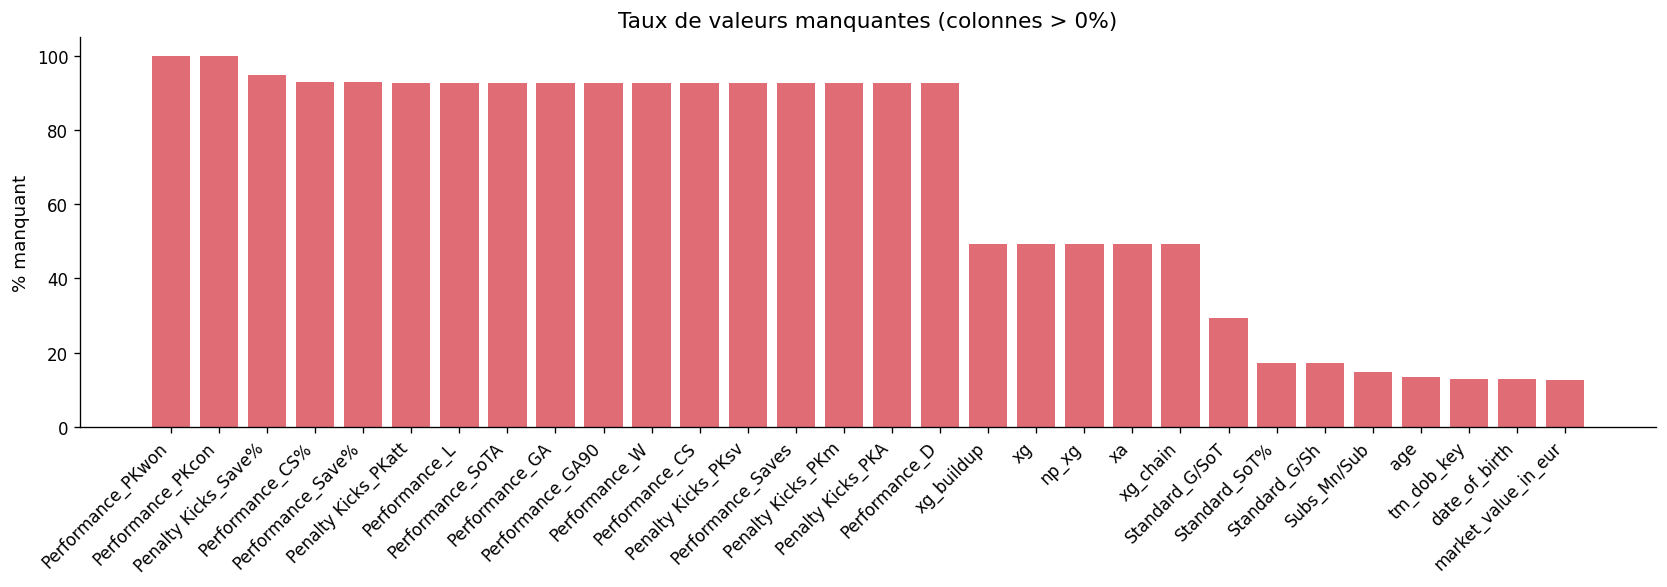

In [100]:
print("Valeurs manquantes")

missing = (
    df.isnull()
    .sum()
    .to_frame("nb_missing")
    .assign(pct=lambda x: (x["nb_missing"] / len(df) * 100).round(2))
    .sort_values("pct", ascending=False)
)
print(missing[missing["nb_missing"] > 0].to_string())

# Heatmap des valeurs manquantes (top 30 colonnes)
top_missing = missing[missing["nb_missing"] > 0].head(30).index
if len(top_missing) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(top_missing, missing.loc[top_missing, "pct"], color="#E06C75")
    ax.set_title("Taux de valeurs manquantes (colonnes > 0%)")
    ax.set_ylabel("% manquant")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(dossier_sortie /"valeurs_manquantes.png")
    print("\nvaleurs_manquantes.png sauvegardé")
    plt.show()

In [88]:
print("Analyse des doublons")

nb_dup = df.duplicated().sum()
print(f"Lignes dupliquées (toutes colonnes) : {nb_dup}")

id_cols = ["player_id", "season"]
if all(c in df.columns for c in id_cols):
    nb_dup_id = df.duplicated(subset=id_cols).sum()
    print(f"Doublons sur ({', '.join(id_cols)}) : {nb_dup_id}")

Analyse des doublons
Lignes dupliquées (toutes colonnes) : 0
Doublons sur (player_id, season) : 3090


Analyse de la variable cible
count         14,932
mean      12,053,886
std       17,101,340
min           50,000
25%        2,200,000
50%        6,000,000
75%       15,000,000
max      200,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.54
Kurtosis : 19.68

distribution_vm.png sauvegardé


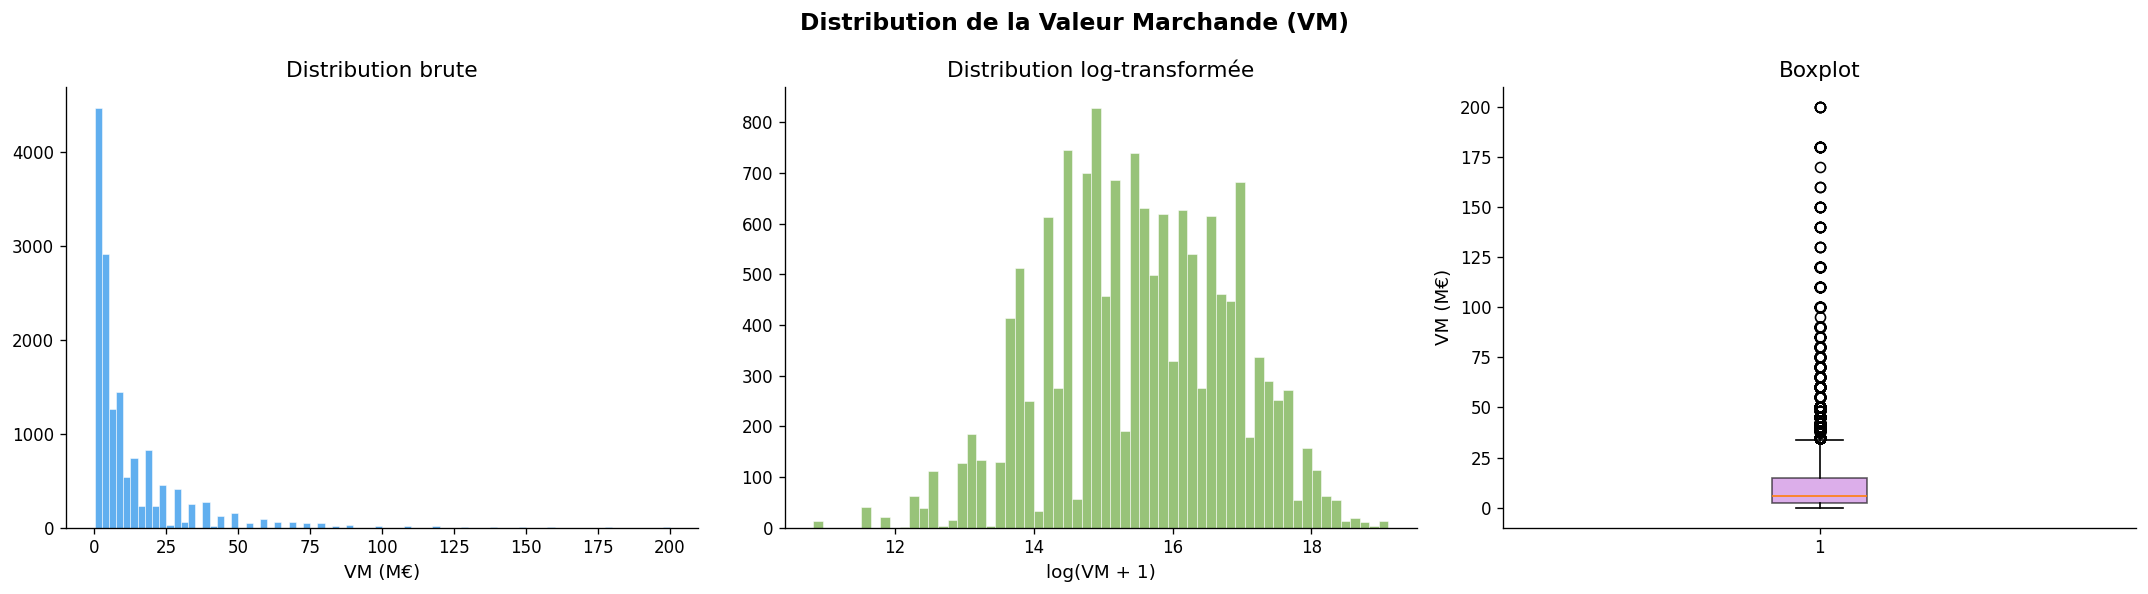

In [102]:
print("Analyse de la variable cible")

vm = df[TARGET].dropna()
print(vm.describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nSkewness : {vm.skew():.2f}")
print(f"Kurtosis : {vm.kurt():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution de la Valeur Marchande (VM)", fontsize=14, fontweight="bold")

# Distribution brute
axes[0].hist(vm / 1e6, bins=80, color="#61AFEF", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("VM (M€)")
axes[0].set_title("Distribution brute")

# Distribution log
vm_log = np.log1p(vm)
axes[1].hist(vm_log, bins=60, color="#98C379", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("log(VM + 1)")
axes[1].set_title("Distribution log-transformée")

# Boxplot
axes[2].boxplot(vm / 1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#C678DD", alpha=0.6))
axes[2].set_ylabel("VM (M€)")
axes[2].set_title("Boxplot")

plt.tight_layout()
plt.savefig(dossier_sortie / "distribution_vm.png")
print("\ndistribution_vm.png sauvegardé")
plt.show()

Distributions des variables numériques clés
distributions_variables_numériques_clés.png sauvegardé


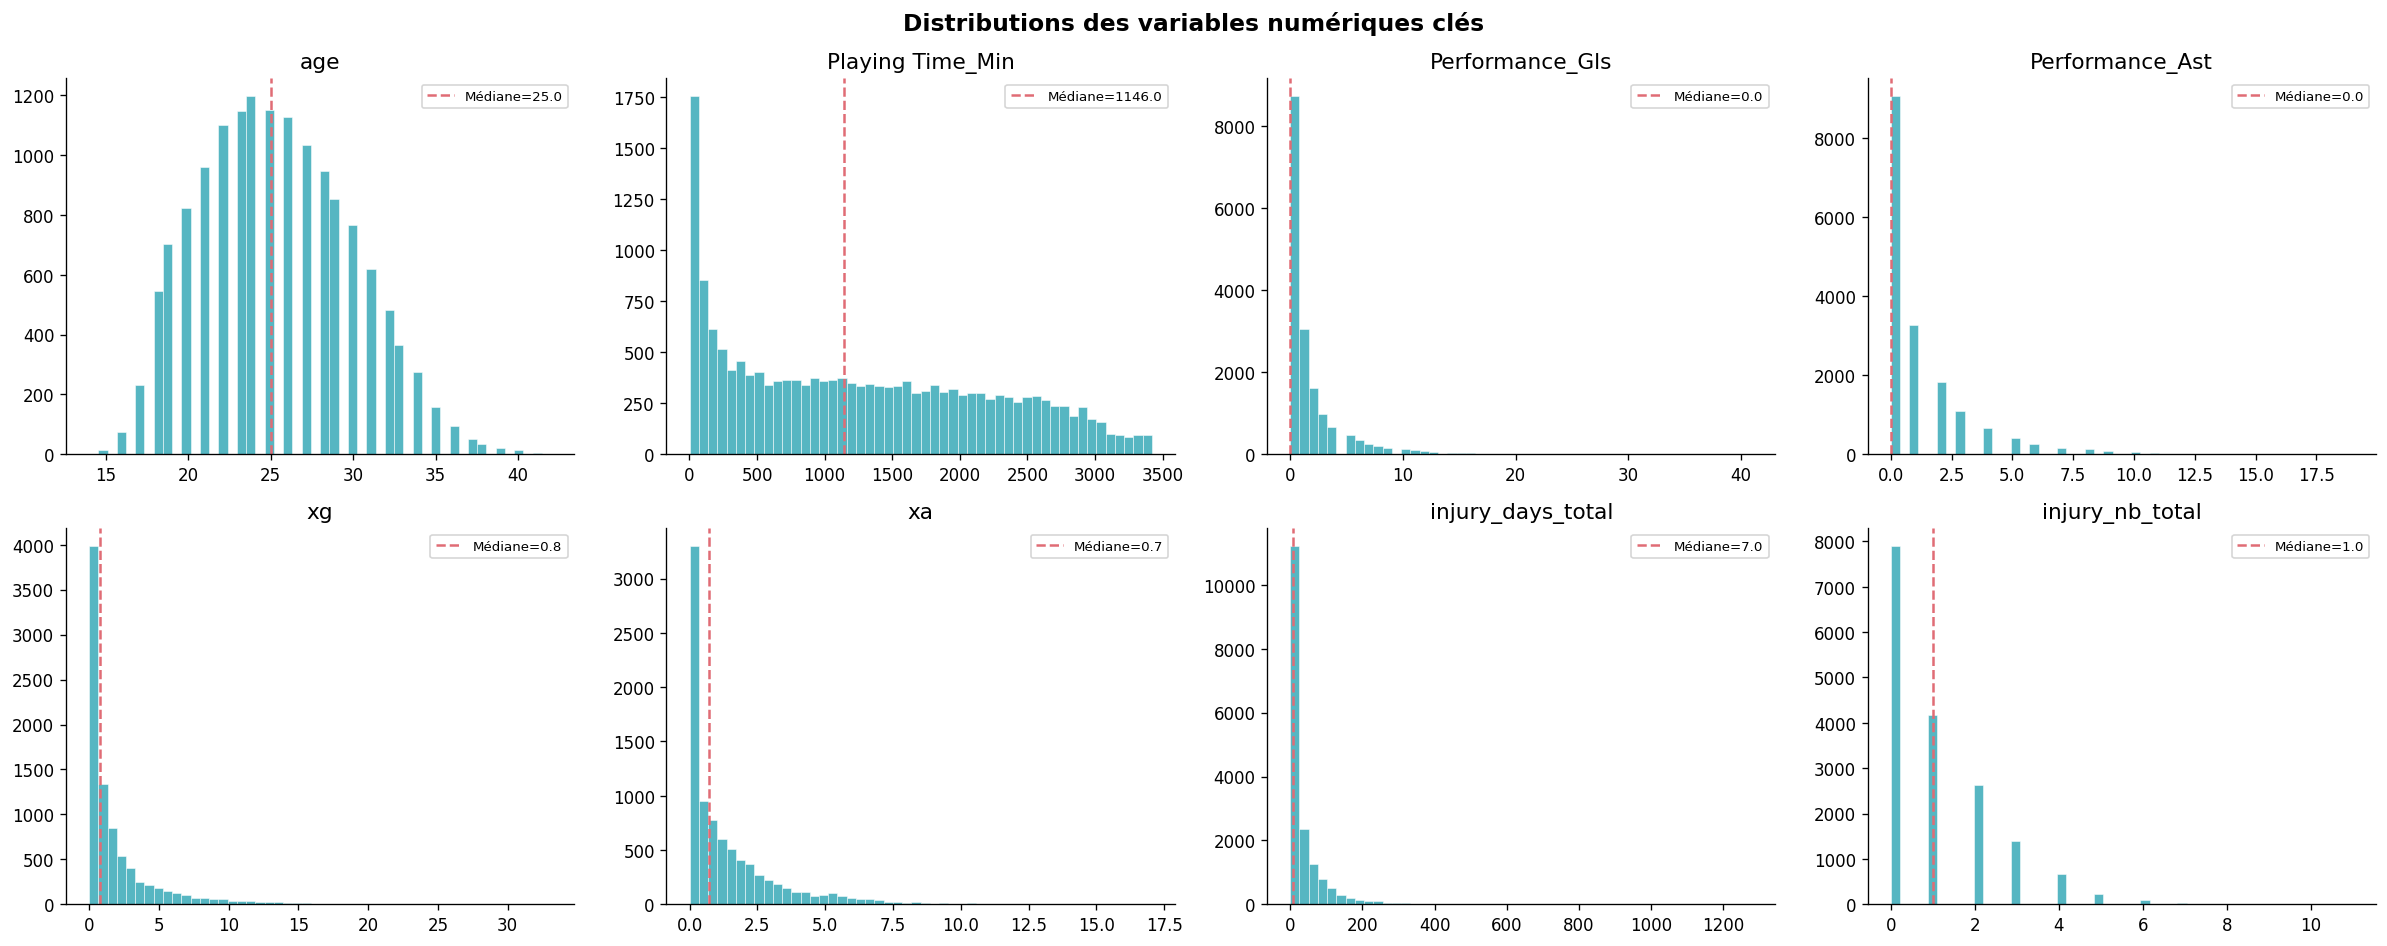

In [103]:
print("Distributions des variables numériques clés")

key_num = [
    "age",
    "Playing Time_Min",
    "Performance_Gls",
    "Performance_Ast",
    "xg", "xa",
    "injury_days_total",
    "injury_nb_total",
]
key_num = [c for c in key_num if c in df.columns]

# Forcer la conversion numérique
n_cols = 4
n_rows = int(np.ceil(len(key_num) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_num):
    data = pd.to_numeric(df[col], errors="coerce").dropna()  # ← correctif ici
    axes[i].hist(data, bins=50, color="#56B6C2", edgecolor="white", linewidth=0.3)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].axvline(data.median(), color="#E06C75", linestyle="--", label=f"Médiane={data.median():.1f}")
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distributions des variables numériques clés", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(dossier_sortie /"distributions_variables_numériques_clés.png")
print("distributions_variables_numériques_clés.png sauvegardé")
plt.show()

Variables catégorielles

pos (10 modalités) :
pos
MF       5266
DF       4336
FW       2194
MF,FW    1298
GK       1258
FW,MF    1086
DF,MF     987
MF,DF     676
DF,FW      19
FW,DF       2

league (5 modalités) :
league
ESP-La Liga           3689
ITA-Serie A           3664
ENG-Premier League    3461
FRA-Ligue 1           3347
GER-Bundesliga        2961

season (6 modalités) :
season
2122    3033
2223    2991
2021    2956
2425    2921
2324    2906
2526    2315

players_top_nations.png sauvegardé


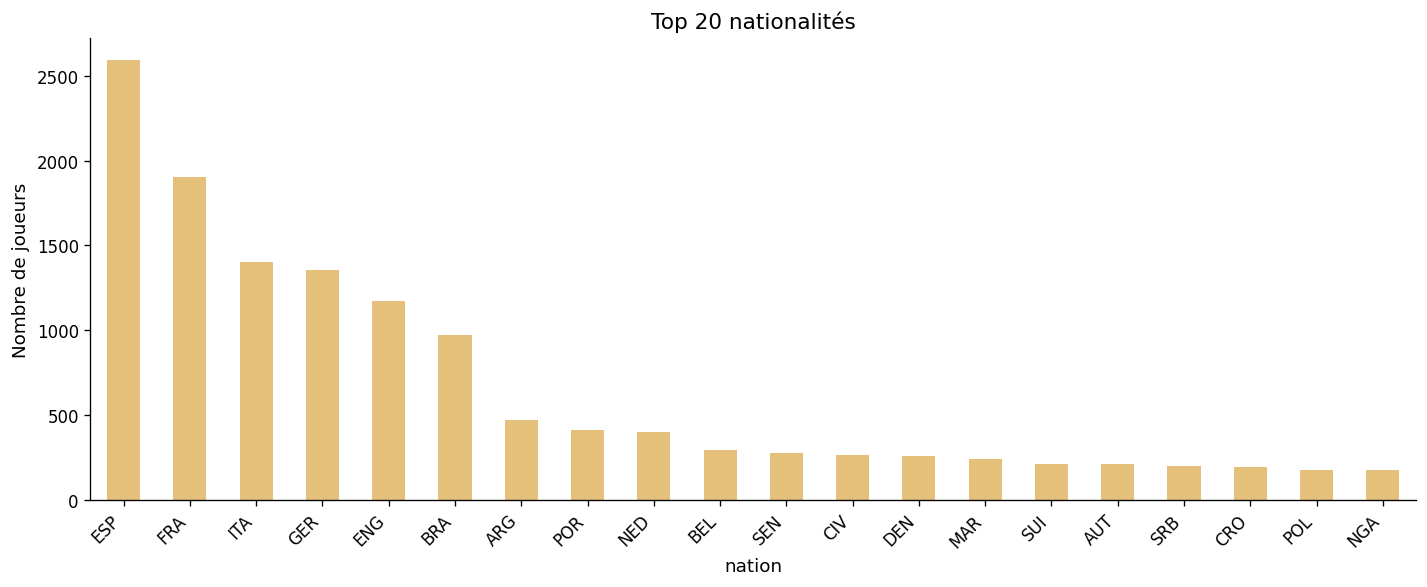

pos.png sauvegardé


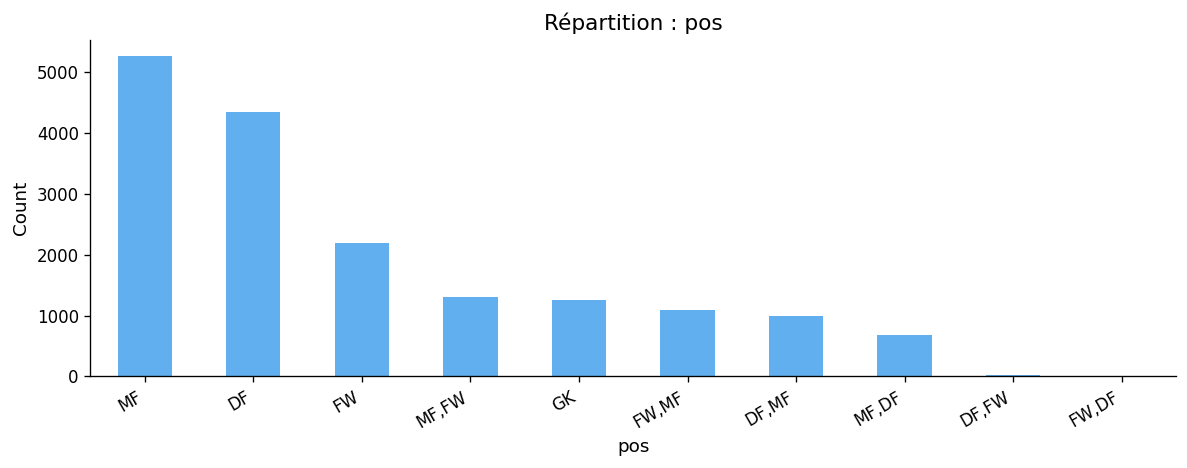

league.png sauvegardé


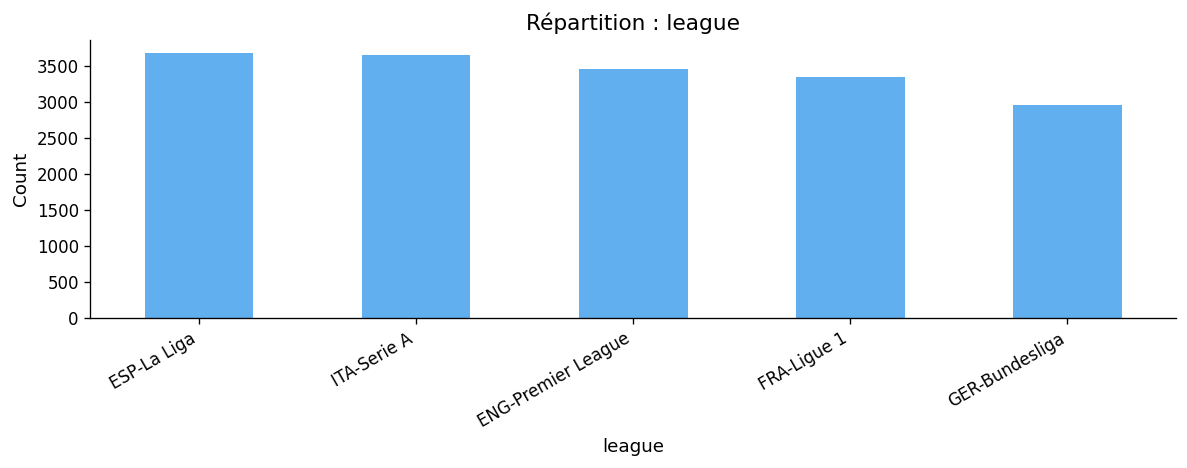

vm_par_pos.png sauvegardé


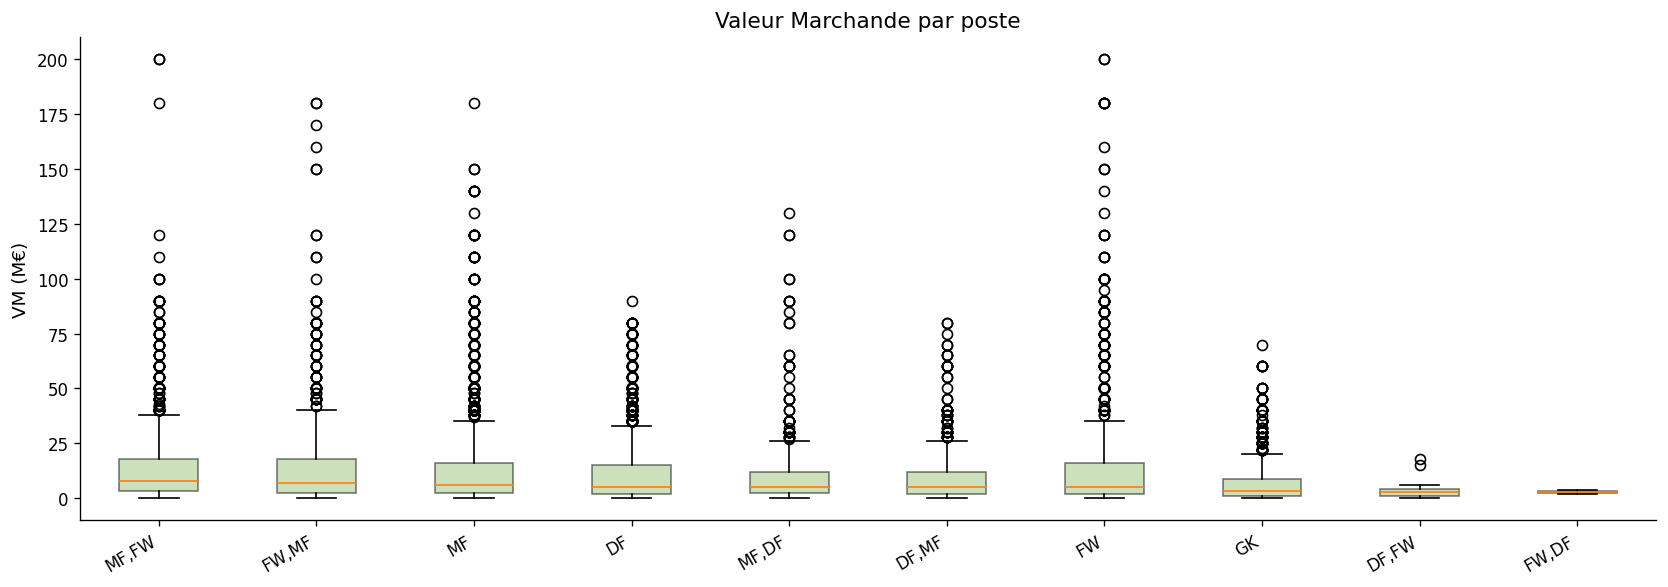

vm_par_league.png sauvegardé


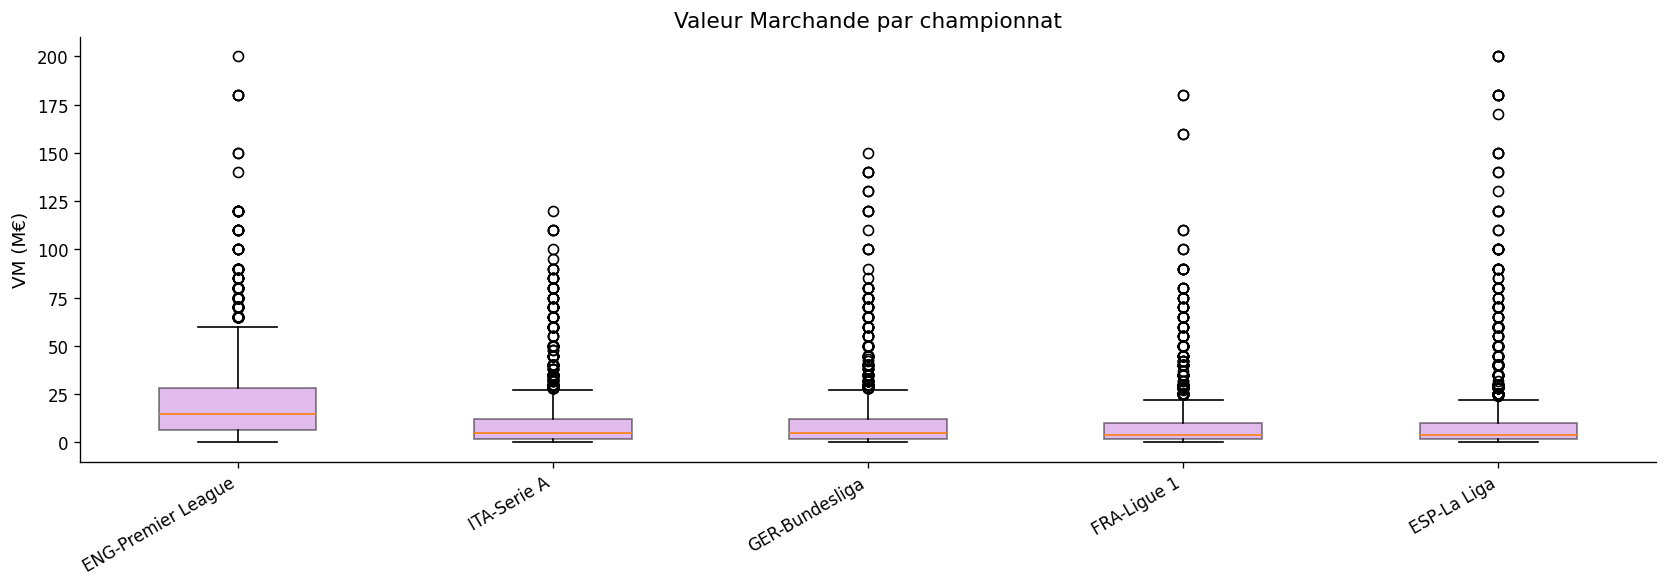

In [104]:
print("Variables catégorielles")

key_cat = ["pos", "league", "season"]
key_cat = [c for c in key_cat if c in df.columns]

for col in key_cat:
    vc = df[col].value_counts()
    print(f"\n{col} ({vc.shape[0]} modalités) :")
    print(vc.head(20).to_string())

# Nationalité : top 20
if "nation" in df.columns:
    top_nations = df["nation"].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_nations.plot(kind="bar", ax=ax, color="#E5C07B")
    ax.set_title("Top 20 nationalités")
    ax.set_ylabel("Nombre de joueurs")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(dossier_sortie /"players_top_nations.png")
    print("\nplayers_top_nations.png sauvegardé")
    plt.show()

# Poste & Championnat
for col in ["pos", "league"]:
    if col not in df.columns:
        continue
    vc = df[col].value_counts()
    fig, ax = plt.subplots(figsize=(10, 4))
    vc.plot(kind="bar", ax=ax, color="#61AFEF")
    ax.set_title(f"Répartition : {col}")
    ax.set_ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(dossier_sortie / f"{col}.png")
    print(f"{col}.png sauvegardé")
    plt.show()

# VM par poste (boxplot)
if "pos" in df.columns:
    df_pos = df[[TARGET, "pos"]].dropna()
    order = df_pos.groupby("pos")[TARGET].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(14, 5))
    groups = [df_pos.loc[df_pos["pos"] == p, TARGET].values / 1e6 for p in order]
    ax.boxplot(groups, labels=order, patch_artist=True,
               boxprops=dict(facecolor="#98C379", alpha=0.5))
    ax.set_title("Valeur Marchande par poste")
    ax.set_ylabel("VM (M€)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(dossier_sortie / "vm_par_pos.png")
    print("vm_par_pos.png sauvegardé")
    plt.show()

# VM par championnat
if "league" in df.columns:
    df_ligue = df[[TARGET, "league"]].dropna()
    order_l = df_ligue.groupby("league")[TARGET].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(14, 5))
    groups_l = [df_ligue.loc[df_ligue["league"] == l, TARGET].values / 1e6 for l in order_l]
    ax.boxplot(groups_l, labels=order_l, patch_artist=True,
               boxprops=dict(facecolor="#C678DD", alpha=0.5))
    ax.set_title("Valeur Marchande par championnat")
    ax.set_ylabel("VM (M€)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(dossier_sortie / "vm_par_league.png")
    print("vm_par_league.png sauvegardé")
    plt.show()

In [93]:
print("Détection des outliers")

outlier_report = []
for col in key_num:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_iqr = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    z = np.abs(stats.zscore(s))
    n_z = (z > 3).sum()
    outlier_report.append({"variable": col, "outliers_IQR": n_iqr, "outliers_Zscore": n_z, "total": len(s)})

df_out = pd.DataFrame(outlier_report)
df_out["pct_IQR"] = (df_out["outliers_IQR"] / df_out["total"] * 100).round(1)
print(df_out.to_string(index=False))

Détection des outliers
         variable  outliers_IQR  outliers_Zscore  total  pct_IQR
              age            19               19  14806      0.1
 Playing Time_Min             0                0  17122      0.0
  Performance_Gls          1581              374  17122      9.2
  Performance_Ast           768              339  17122      4.5
               xg           807              206   8689      9.3
               xa           592              168   8689      6.8
injury_days_total          1442              382  17122      8.4
  injury_nb_total           121              121  17122      0.7


Relations entre variables et VM
relations_vm.png sauvegardé


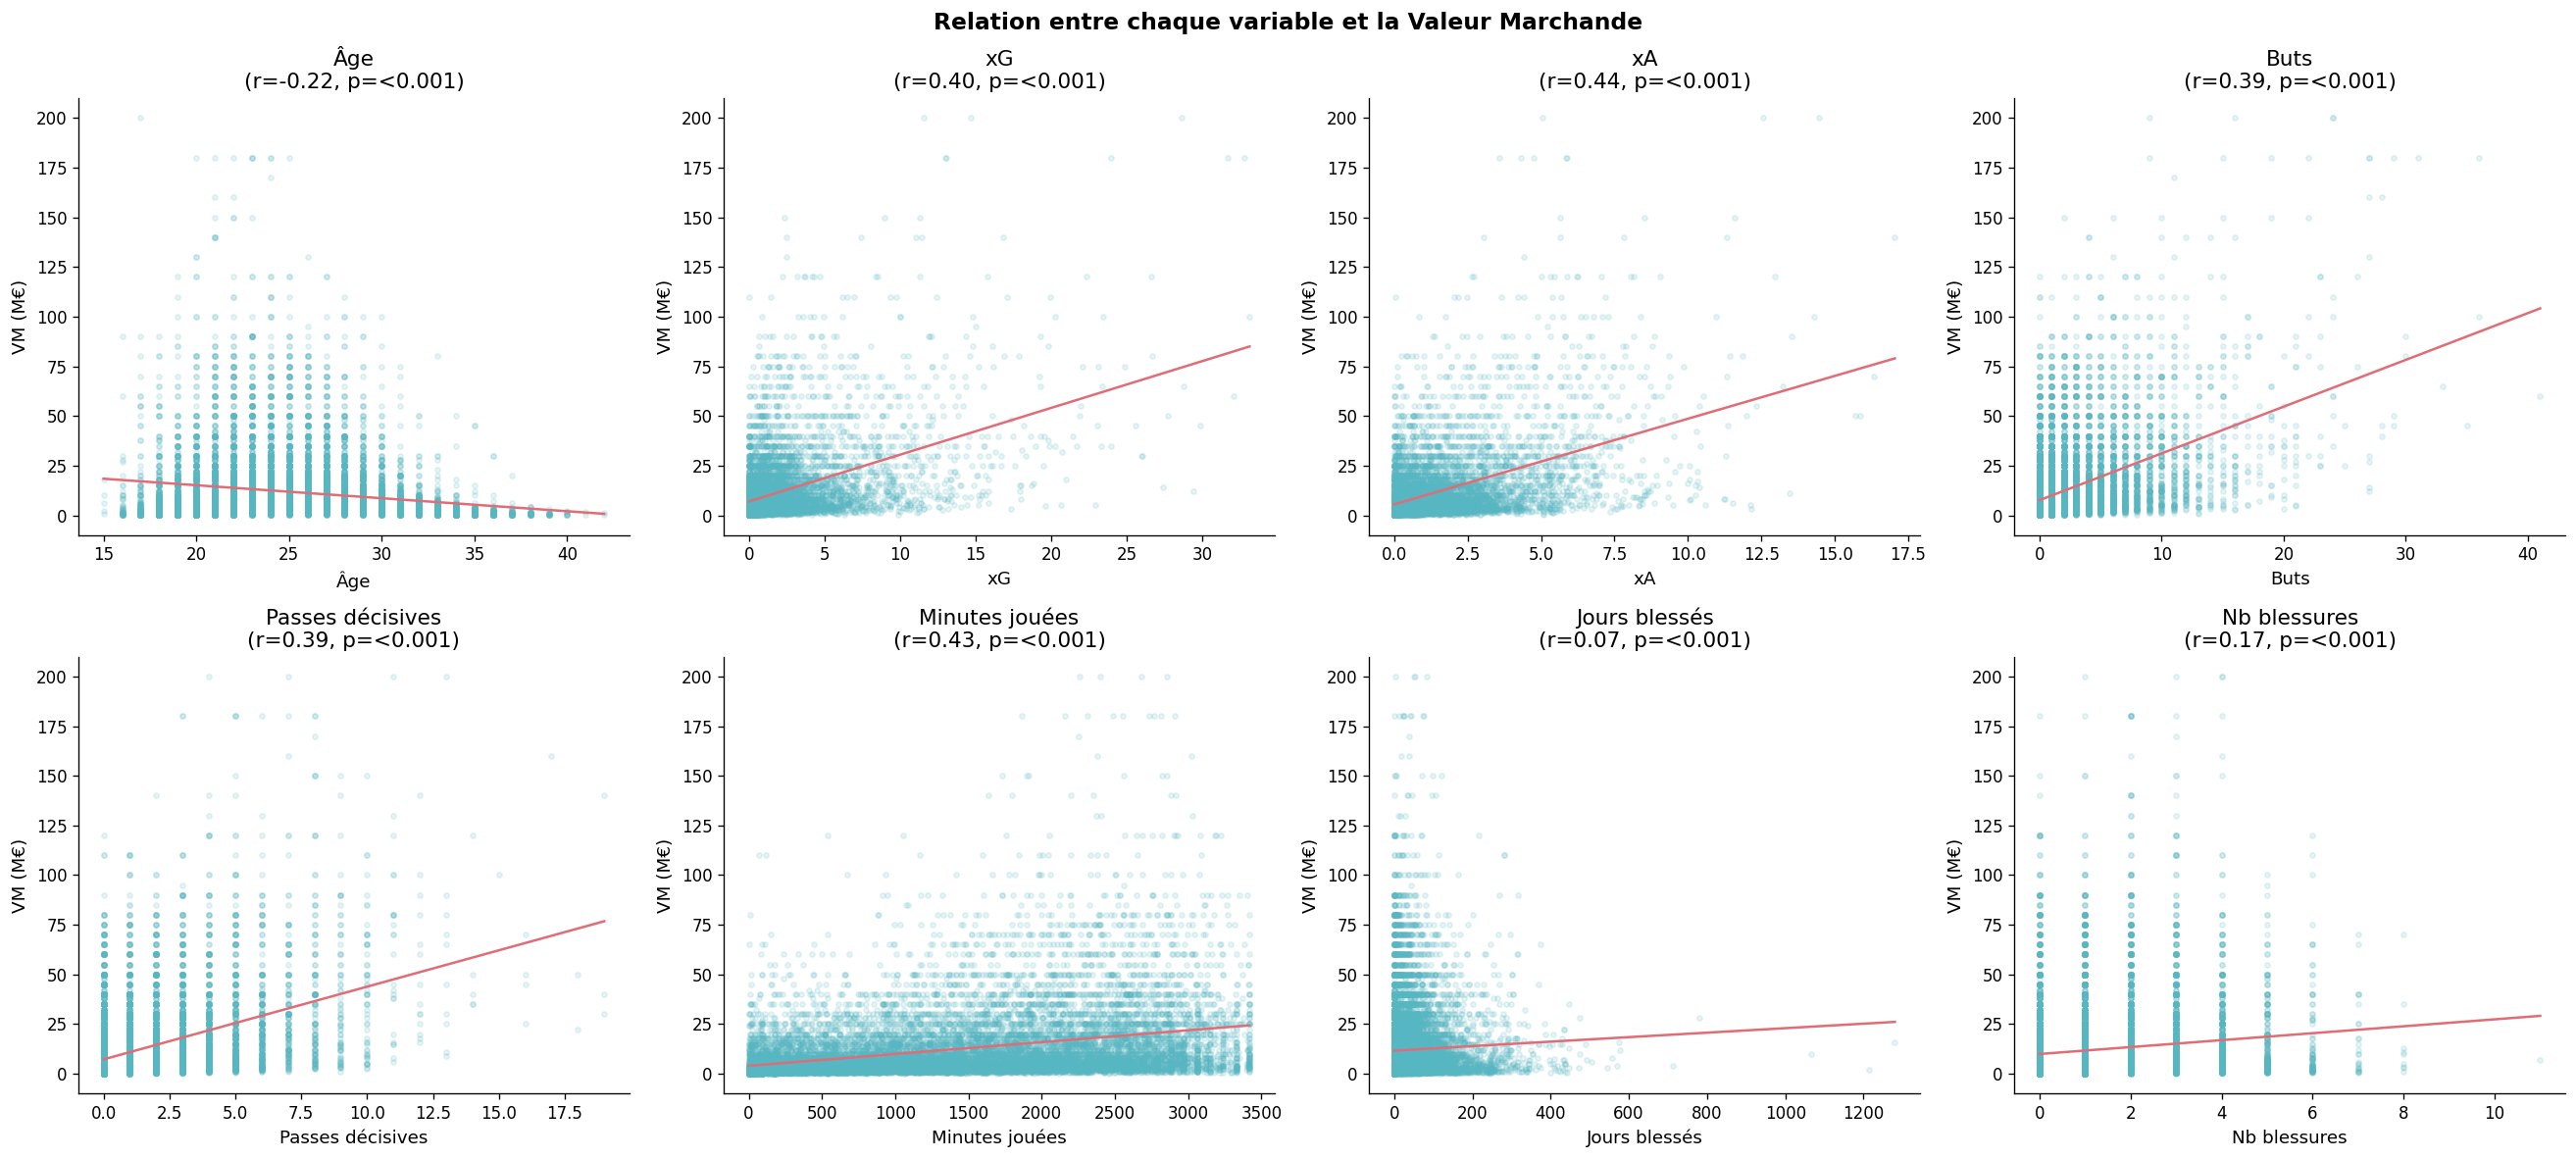

In [105]:
print("Relations entre variables et VM")

scatter_vars = [
    ("age",                  "Âge"),
    ("xg",                   "xG"),
    ("xa",                   "xA"),
    ("Performance_Gls",      "Buts"),
    ("Performance_Ast",      "Passes décisives"),
    ("Playing Time_Min",     "Minutes jouées"),
    ("injury_days_total",    "Jours blessés"),
    ("injury_nb_total",      "Nb blessures"),
]
scatter_vars = [(c, l) for c, l in scatter_vars if c in df.columns]

n_cols_s = 4
n_rows_s = int(np.ceil(len(scatter_vars) / n_cols_s))
fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(22, 5 * n_rows_s))
axes = axes.flatten()

for i, (col, label) in enumerate(scatter_vars):
    sub = df[[col, TARGET]].dropna()
    r, p = stats.pearsonr(sub[col], np.log1p(sub[TARGET]))
    axes[i].scatter(sub[col], sub[TARGET] / 1e6,
                    alpha=0.15, s=10, color="#56B6C2", rasterized=True)
    # droite de régression
    m, b = np.polyfit(sub[col], sub[TARGET] / 1e6, 1)
    x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="#E06C75", linewidth=1.5)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("VM (M€)")
    axes[i].set_title(f"{label}\n(r={r:.2f}, p={'<0.001' if p < 0.001 else f'{p:.3f}'})")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Relation entre chaque variable et la Valeur Marchande", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(dossier_sortie /"relations_vm.png")
print("relations_vm.png sauvegardé")
plt.show()

Matrice de corrélation
                     market_value_in_eur
market_value_in_eur             1.000000
xa                              0.471131
Performance_Gls                 0.453717
xg                              0.448200
Performance_Ast                 0.430721
Playing Time_Min                0.327885
injury_nb_total                 0.136287
injury_days_total               0.040391
age                            -0.175952
matrice_correlation.png sauvegardé


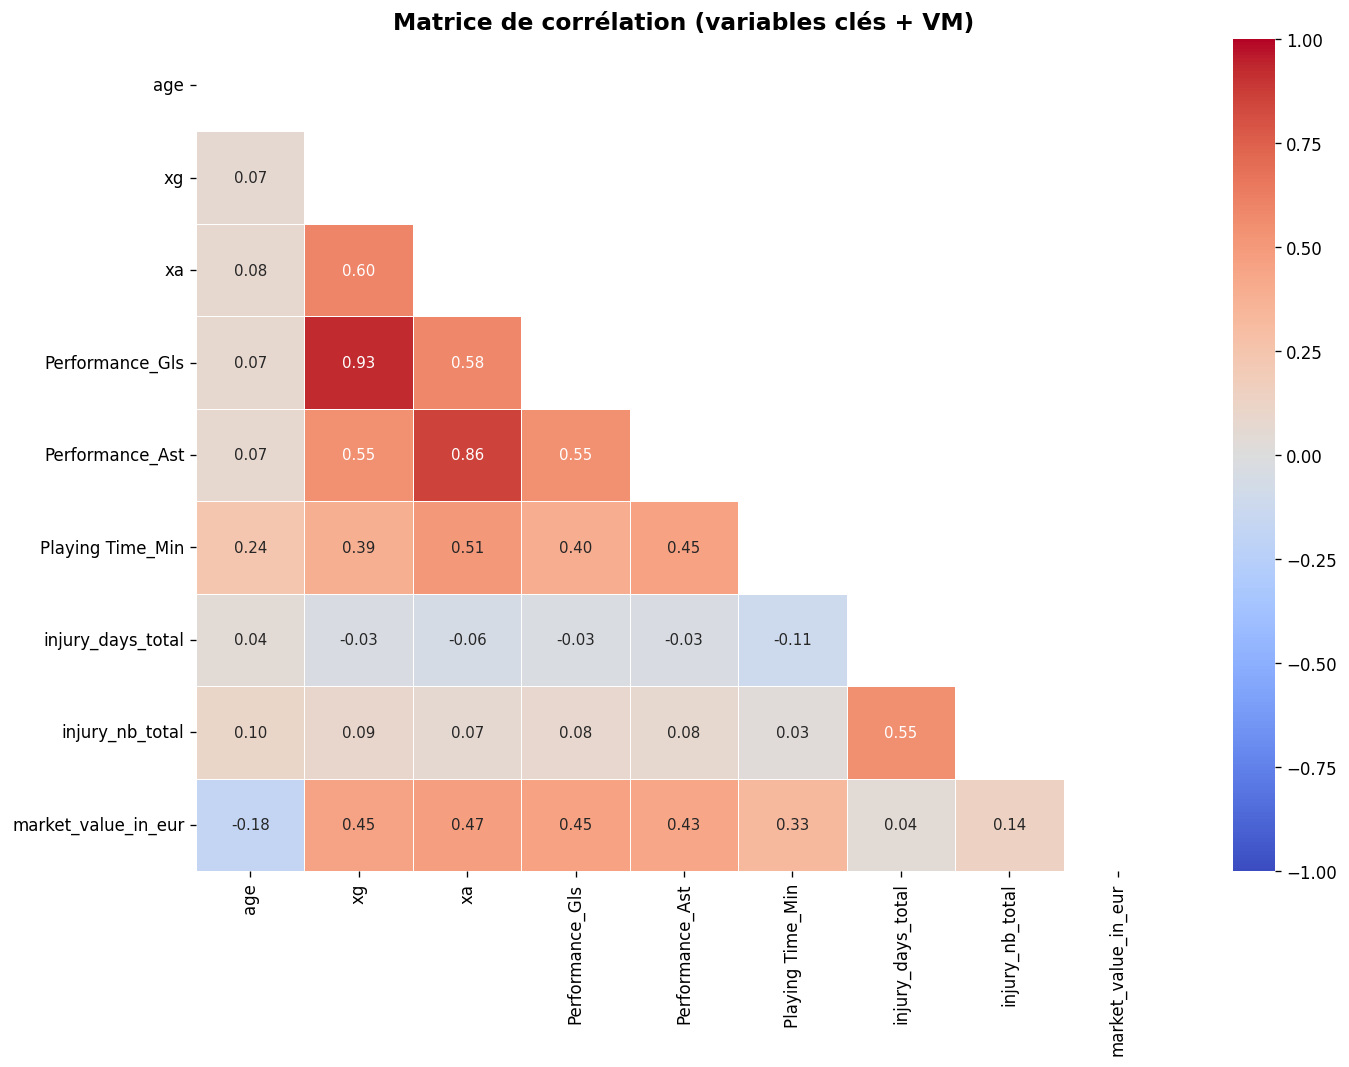


Top 20 corrélations avec la VM (toutes variables numériques)
Performance_W          0.624231
xg_chain               0.618251
Performance_CS         0.567894
Team Success_onG       0.516945
xg_buildup             0.513561
Performance_G+A        0.503421
Team Success_+/-       0.503157
xa                     0.471131
Standard_Sh            0.470121
Standard_SoT           0.466856
np_xg                  0.460754
Performance_G-PK       0.459572
Performance_Gls        0.453717
Standard_Gls           0.453717
xg                     0.448200
Performance_Ast        0.430721
Team Success_PPM       0.355746
Performance_Saves      0.342130
Playing Time_Starts    0.328627
Starts_Starts          0.328627


In [106]:
print("Matrice de corrélation")

corr_vars = [c for c, _ in scatter_vars] + [TARGET]
corr_vars = [c for c in corr_vars if c in df.columns]

corr_matrix = df[corr_vars].corr()

print(corr_matrix[[TARGET]].sort_values(TARGET, ascending=False).to_string())

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Matrice de corrélation (variables clés + VM)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(dossier_sortie /"matrice_correlation.png")
print("matrice_correlation.png sauvegardé")
plt.show()

# Corrélation complète (toutes variables numériques) avec VM
print("\nTop 20 corrélations avec la VM (toutes variables numériques)")
num_cols_unique = [c for c in num_cols if c != TARGET]

full_corr = (
    df[num_cols_unique + [TARGET]]
    .apply(pd.to_numeric, errors="coerce")
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
print(full_corr.head(20).to_string())

Segmentation par poste
segmentation_par_poste_profil_poste.png sauvegardé


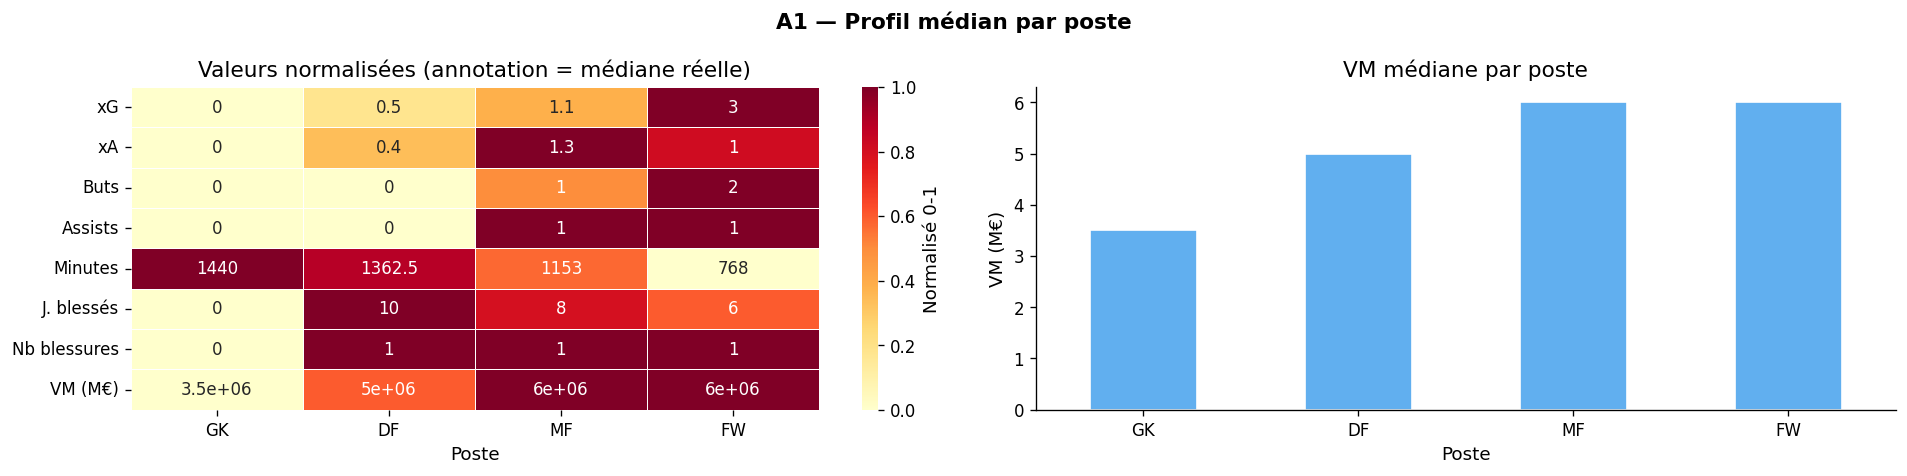

In [108]:
print("Segmentation par poste")

pos_order = ["GK", "DF", "MF", "FW"]
df_pos = df[df["pos_simple"].isin(pos_order)].copy()

# Profil moyen normalisé par poste
profile_cols = {
    "xG":            "xg",
    "xA":            "xa",
    "Buts":          "Performance_Gls",
    "Assists":       "Performance_Ast",
    "Minutes":       "Playing Time_Min",
    "J. blessés":    "injury_days_total",
    "Nb blessures":  "injury_nb_total",
    "VM (M€)":       TARGET,
}
profile_cols = {k: v for k, v in profile_cols.items() if v in df.columns}

profile = (
    df_pos.groupby("pos_simple")[list(profile_cols.values())]
    .median()
    .reindex(pos_order)
)
profile.columns = list(profile_cols.keys())

# Normalisation min-max par colonne pour comparaison visuelle
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("A1 — Profil médian par poste", fontsize=13, fontweight="bold")

sns.heatmap(profile_norm.T, annot=profile.T.round(1), fmt="g",
            cmap="YlOrRd", ax=axes[0], linewidths=0.5, cbar_kws={"label":"Normalisé 0-1"})
axes[0].set_title("Valeurs normalisées (annotation = médiane réelle)")
axes[0].set_xlabel("Poste")

# Valeurs brutes VM
vm_by_pos = df_pos.groupby("pos_simple")[TARGET].median().reindex(pos_order) / 1e6
vm_by_pos.plot(kind="bar", ax=axes[1], color=COLORS["blue"], edgecolor="white")
axes[1].set_title("VM médiane par poste")
axes[1].set_ylabel("VM (M€)")
axes[1].set_xlabel("Poste")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(dossier_sortie /"segmentation_par_poste_profil_poste.png")
print("segmentation_par_poste_profil_poste.png sauvegardé")
plt.show()

segmentation_par_poste_corr_poste.png sauvegardé


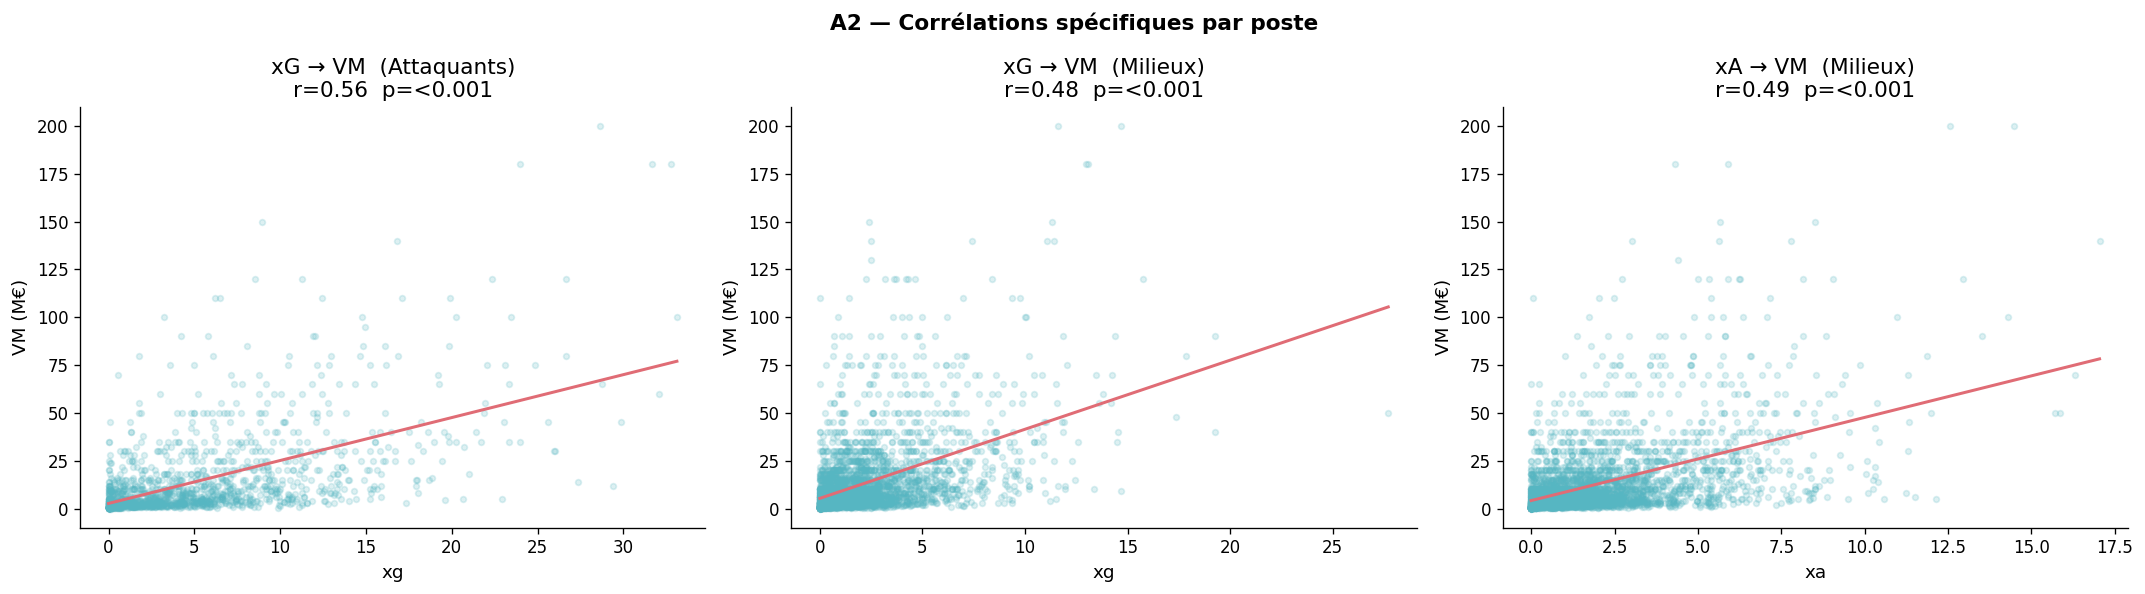

In [109]:
# Corrélations xG/VM (FW/MF) et xA/VM (MF)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("A2 — Corrélations spécifiques par poste", fontsize=13, fontweight="bold")

pairs = [
    ("FW", "xg",  "xG → VM  (Attaquants)"),
    ("MF", "xg",  "xG → VM  (Milieux)"),
    ("MF", "xa",  "xA → VM  (Milieux)"),
]

for ax, (pos, feat, title) in zip(axes, pairs):
    sub = df_pos[(df_pos["pos_simple"] == pos) & df_pos[[feat, TARGET]].notna().all(axis=1)]
    r, p = pearsonr(sub[feat], np.log1p(sub[TARGET]))
    ax.scatter(sub[feat], sub[TARGET] / 1e6, alpha=0.2, s=12,
               color=COLORS["cyan"], rasterized=True)
    m, b = np.polyfit(sub[feat], sub[TARGET] / 1e6, 1)
    x_l = np.linspace(sub[feat].min(), sub[feat].max(), 100)
    ax.plot(x_l, m * x_l + b, color=COLORS["red"], lw=1.8)
    ax.set_title(f"{title}\nr={r:.2f}  p={'<0.001' if p<0.001 else f'{p:.3f}'}")
    ax.set_xlabel(feat)
    ax.set_ylabel("VM (M€)")

plt.tight_layout()
plt.savefig(dossier_sortie /"segmentation_par_poste_corr_poste.png")
print("segmentation_par_poste_corr_poste.png sauvegardé")
plt.show()

segmentation_par_poste_age_par_poste.png sauvegardé


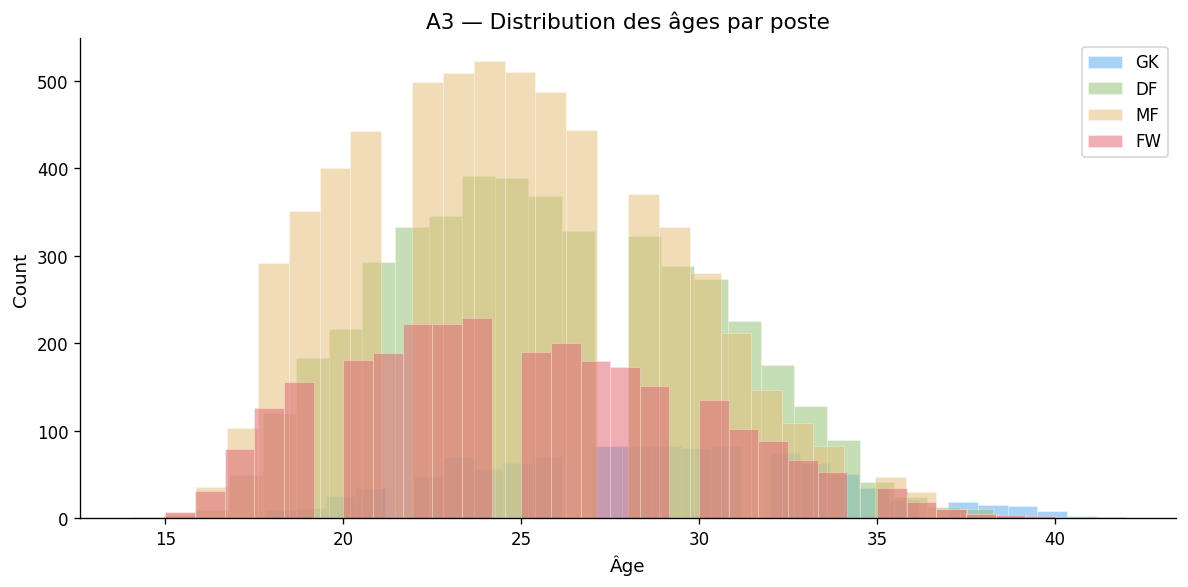


Âge médian par poste :
pos_simple
GK    28.0
DF    25.0
MF    24.0
FW    24.0


In [111]:
# Distribution des âges par poste
fig, ax = plt.subplots(figsize=(10, 5))
for pos, color in zip(pos_order, [COLORS["blue"], COLORS["green"], COLORS["yellow"], COLORS["red"]]):
    ages = df_pos[df_pos["pos_simple"] == pos]["age"].dropna()
    ax.hist(ages, bins=30, alpha=0.55, label=pos, color=color, edgecolor="white", linewidth=0.3)
ax.set_title("A3 — Distribution des âges par poste")
ax.set_xlabel("Âge")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(dossier_sortie /"segmentation_par_poste_age_par_poste.png")
print("segmentation_par_poste_age_par_poste.png sauvegardé")
plt.show()

# Stats
print("\nÂge médian par poste :")
print(df_pos.groupby("pos_simple")["age"].median().reindex(pos_order).round(1).to_string())

Feature engineering exploratoire
feature_engineering.png sauvegardé


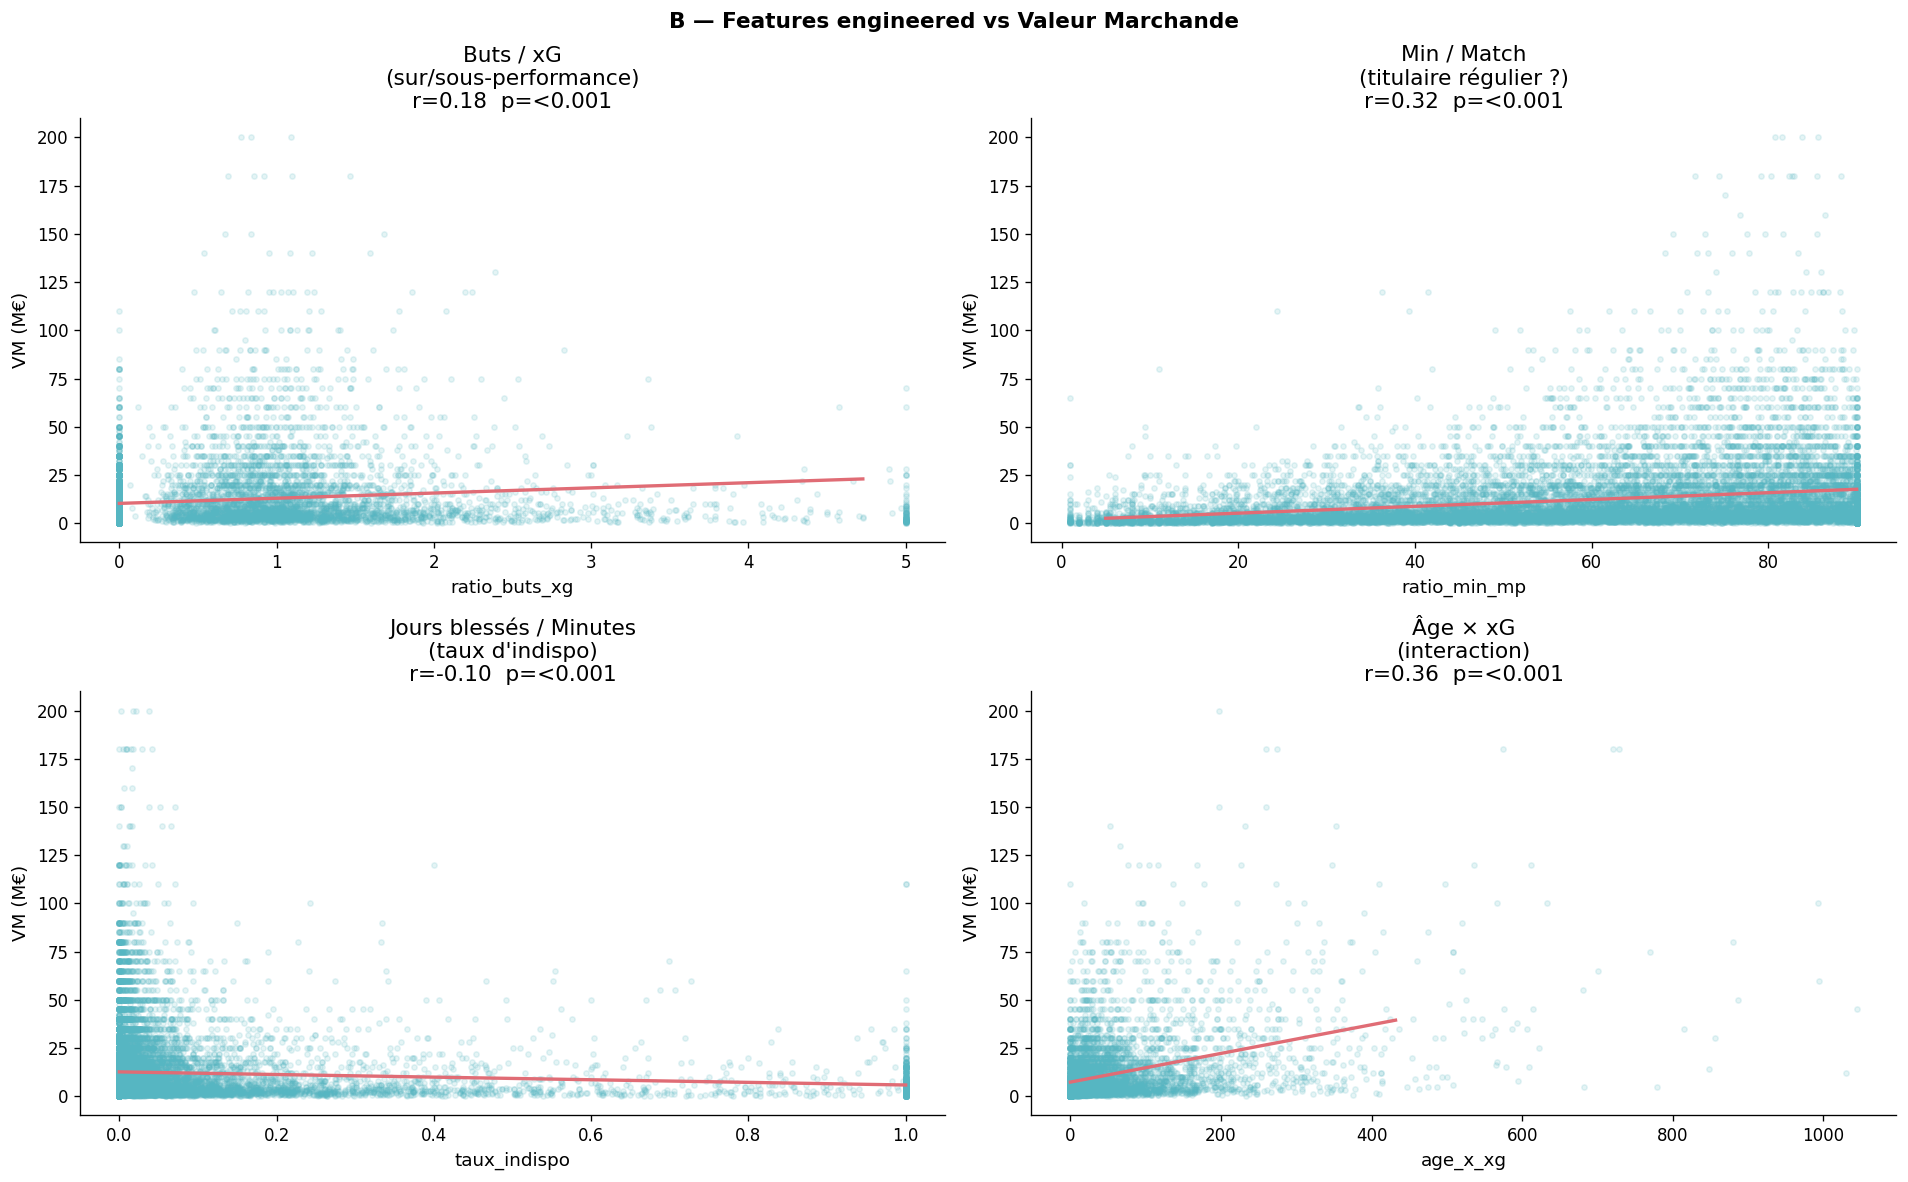


Corrélations (Pearson sur log VM) — features engineered :
  ratio_buts_xg        r=+0.183  p=<0.001
  ratio_min_mp         r=+0.319  p=<0.001
  taux_indispo         r=-0.103  p=<0.001
  age_x_xg             r=+0.364  p=<0.001


In [112]:
print("Feature engineering exploratoire")

dfe = df.copy()

# Calcul des features engineered
dfe["ratio_buts_xg"]      = (dfe["Performance_Gls"] / (dfe["xg"] + 1e-6)).clip(upper=5)
dfe["ratio_min_mp"]       = (dfe["Playing Time_Min"] / (dfe["Playing Time_MP"] + 1e-6))
dfe["taux_indispo"]       = (dfe["injury_days_total"] / (dfe["Playing Time_Min"] + 1)).clip(upper=1)
dfe["age_x_xg"]           = dfe["age"] * dfe["xg"]

new_features = {
    "ratio_buts_xg":  "Buts / xG\n(sur/sous-performance)",
    "ratio_min_mp":   "Min / Match\n(titulaire régulier ?)",
    "taux_indispo":   "Jours blessés / Minutes\n(taux d'indispo)",
    "age_x_xg":       "Âge × xG\n(interaction)",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("B — Features engineered vs Valeur Marchande", fontsize=13, fontweight="bold")
axes = axes.flatten()

for ax, (feat, label) in zip(axes, new_features.items()):
    sub = dfe[[feat, TARGET]].dropna()
    sub = sub[np.isfinite(sub[feat]) & np.isfinite(sub[TARGET])]
    r, p = pearsonr(sub[feat], np.log1p(sub[TARGET]))
    ax.scatter(sub[feat], sub[TARGET] / 1e6, alpha=0.15, s=10,
               color=COLORS["cyan"], rasterized=True)
    m, b = np.polyfit(sub[feat], sub[TARGET] / 1e6, 1)
    x_l = np.linspace(sub[feat].quantile(0.01), sub[feat].quantile(0.99), 100)
    ax.plot(x_l, m * x_l + b, color=COLORS["red"], lw=2)
    ax.set_title(f"{label}\nr={r:.2f}  p={'<0.001' if p<0.001 else f'{p:.3f}'}")
    ax.set_xlabel(feat)
    ax.set_ylabel("VM (M€)")

plt.tight_layout()
plt.savefig(dossier_sortie /"feature_engineering.png")
print("feature_engineering.png sauvegardé")
plt.show()

# Résumé corrélations
print("\nCorrélations (Pearson sur log VM) — features engineered :")
for feat, label in new_features.items():
    sub = dfe[[feat, TARGET]].dropna()
    sub = sub[np.isfinite(sub[feat]) & np.isfinite(sub[TARGET])]
    r, p = pearsonr(sub[feat], np.log1p(sub[TARGET]))
    print(f"  {feat:<20} r={r:+.3f}  p={'<0.001' if p<0.001 else f'{p:.3f}'}")


feature_engineered_heatmap_league_pos.png sauvegardé


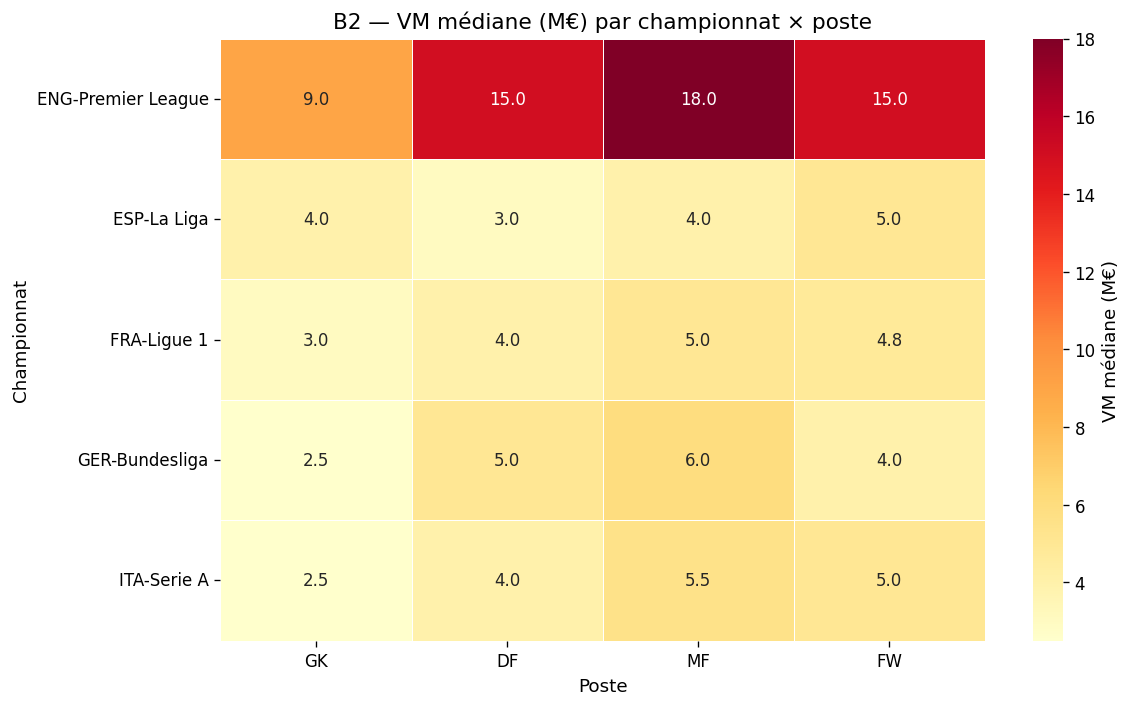

In [114]:
# Heatmap VM médiane par league et poste

print()
pivot = (
    df[df["pos_simple"].isin(pos_order)]
    .groupby(["league", "pos_simple"])[TARGET]
    .median()
    .unstack("pos_simple")
    .reindex(columns=pos_order)
    / 1e6
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot.round(1), annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "VM médiane (M€)"})
ax.set_title("B2 — VM médiane (M€) par championnat × poste")
ax.set_xlabel("Poste")
ax.set_ylabel("Championnat")
plt.tight_layout()
plt.savefig(dossier_sortie /"feature_engineered_heatmap_league_pos.png")
print("feature_engineered_heatmap_league_pos.png sauvegardé")
plt.show()

feature_engineered_violin_league.png sauvegardé


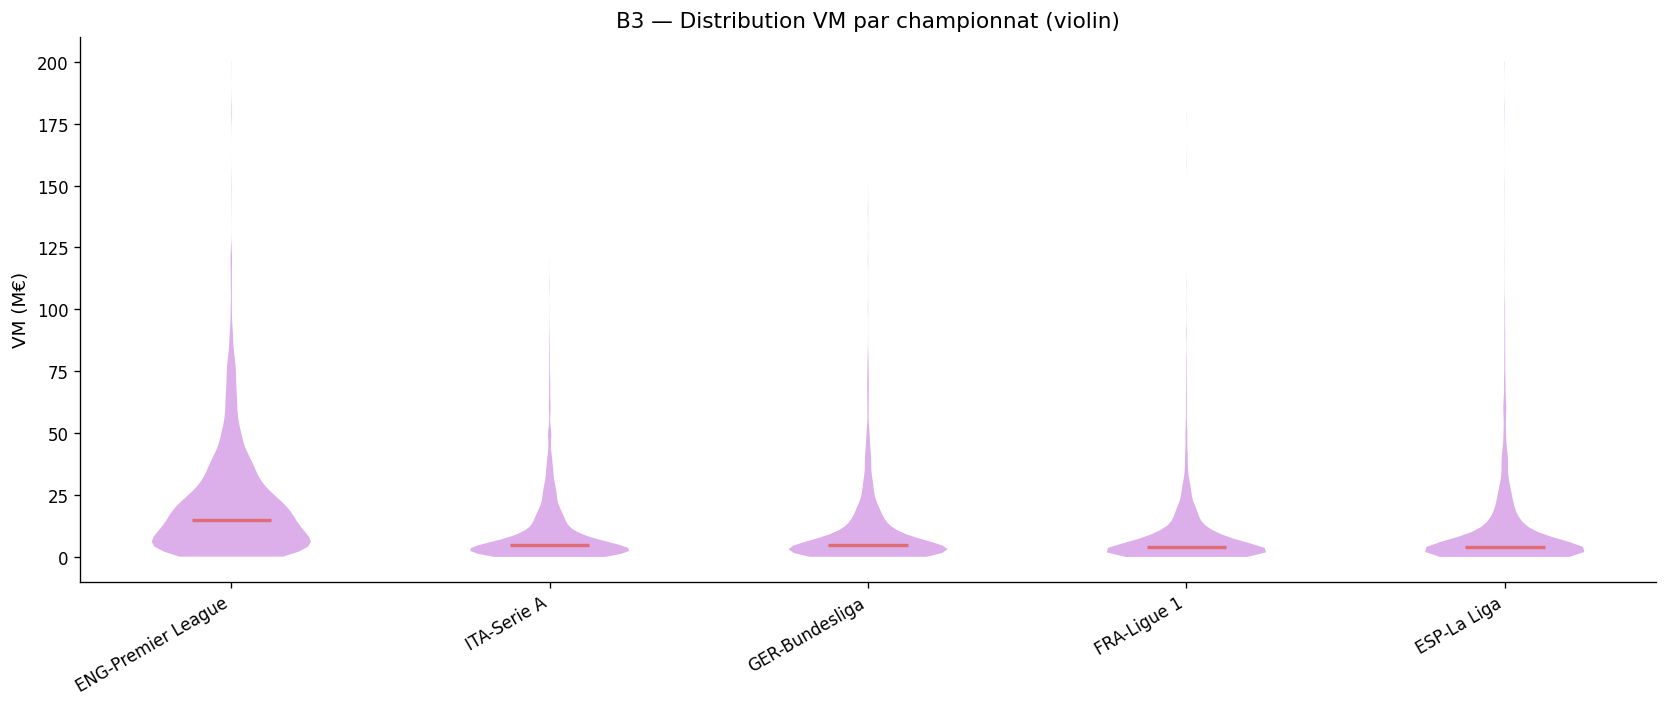

In [115]:
# Violin plot VM par championnat
leagues = df["league"].value_counts().index.tolist()
df_ligue = df[df["league"].isin(leagues)].copy()
order_vm = df_ligue.groupby("league")[TARGET].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
data_violin = [df_ligue[df_ligue["league"] == l][TARGET].dropna().values / 1e6 for l in order_vm]
parts = ax.violinplot(data_violin, showmedians=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor(COLORS["purple"])
    pc.set_alpha(0.6)
parts["cmedians"].set_color(COLORS["red"])
parts["cmedians"].set_linewidth(2)
ax.set_xticks(range(1, len(order_vm) + 1))
ax.set_xticklabels(order_vm, rotation=30, ha="right")
ax.set_title("B3 — Distribution VM par championnat (violin)")
ax.set_ylabel("VM (M€)")
plt.tight_layout()
plt.savefig(dossier_sortie /"feature_engineered_violin_league.png")
print("feature_engineered_violin_league.png sauvegardé")
plt.show()

Analyse des outliers et profils spécifiques

Joueurs avec VM ≥ 100M€ : 81 observations
         player pos_simple             league season_label  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
 Erling Haaland         FW ENG-Premier League      2025/26  NaN                200.0 28.638352               24                4.0
   Lamine Yamal         MF        ESP-La Liga      2025/26  NaN                200.0 14.664690               16               84.0
  Kylian Mbappé         FW        ESP-La Liga      2025/26  NaN                200.0       NaN               24               52.0
   Lamine Yamal         MF        ESP-La Liga      2024/25 17.0                200.0 11.593034                9               50.0
Jude Bellingham         MF        ESP-La Liga      2023/24 20.0                180.0 12.974516               19               40.0
 Erling Haaland         FW ENG-Premier League      2024/25 24.0                180.0 23.954593               22               4

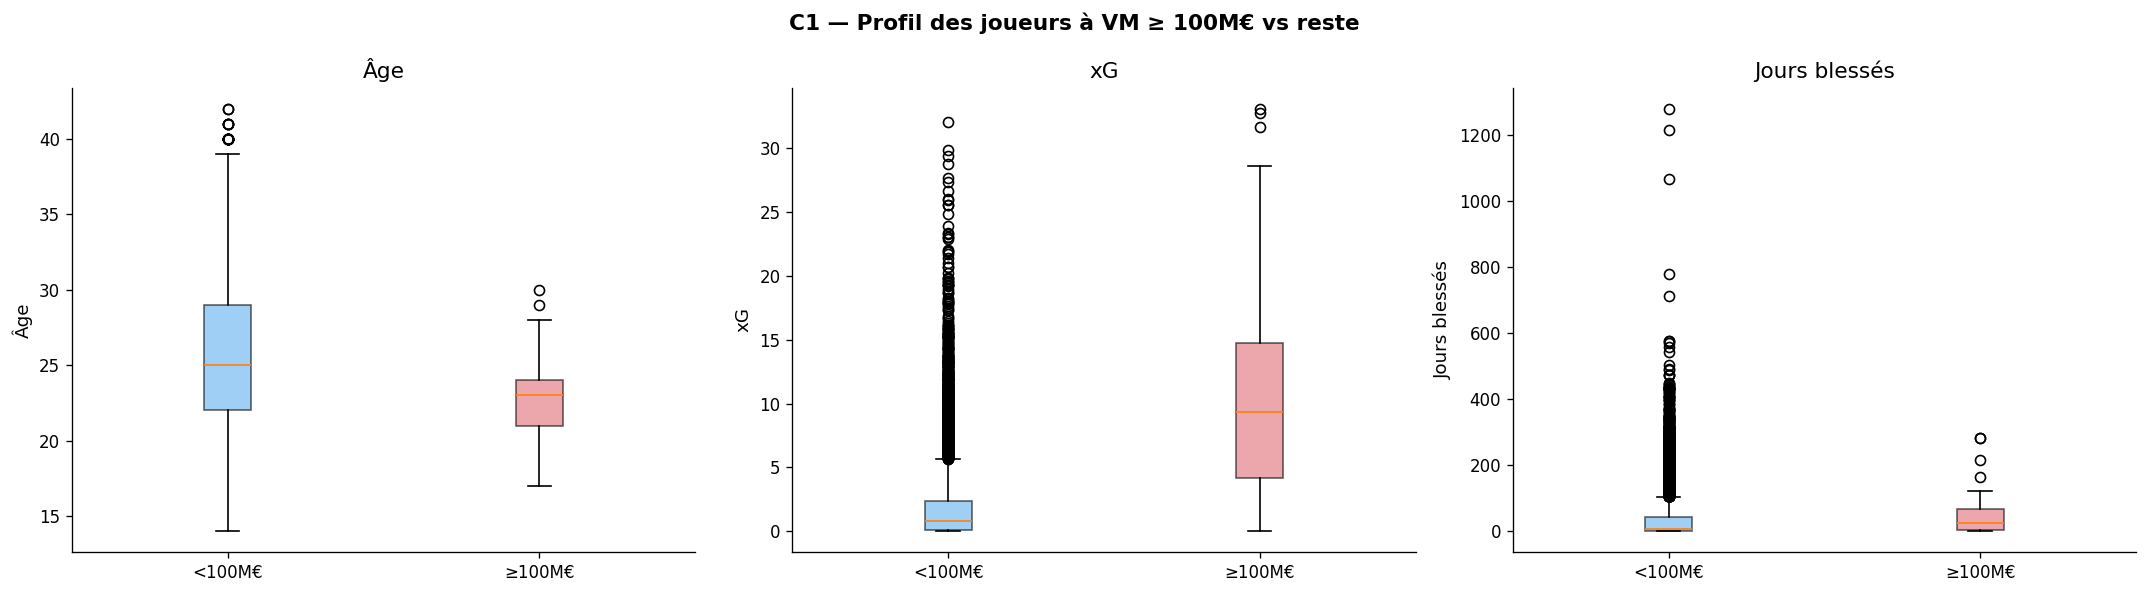

In [117]:
print("Analyse des outliers et profils spécifiques")

# Profil des joueurs > 100M€
df_top = df[df[TARGET] >= 100e6].copy()
print(f"\nJoueurs avec VM ≥ 100M€ : {len(df_top)} observations")

if len(df_top) > 0:
    id_cols_show = ["player", "pos_simple", "league", "season_label", "age",
                    TARGET, "xg", "Performance_Gls", "injury_days_total"]
    id_cols_show = [c for c in id_cols_show if c in df_top.columns]
    top_display = df_top[id_cols_show].sort_values(TARGET, ascending=False).head(20)
    top_display[TARGET] = (top_display[TARGET] / 1e6).round(1)
    print(top_display.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("C1 — Profil des joueurs à VM ≥ 100M€ vs reste", fontsize=13, fontweight="bold")

    df["group"] = np.where(df[TARGET] >= 100e6, "≥100M€", "<100M€")

    for ax, (feat, label) in zip(axes, [
        ("age",               "Âge"),
        ("xg",                "xG"),
        ("injury_days_total", "Jours blessés"),
    ]):
        groups = [df[df["group"] == g][feat].dropna().values for g in ["<100M€", "≥100M€"]]
        bp = ax.boxplot(groups, labels=["<100M€", "≥100M€"], patch_artist=True,
                        boxprops=dict(alpha=0.6))
        bp["boxes"][0].set_facecolor(COLORS["blue"])
        bp["boxes"][1].set_facecolor(COLORS["red"])
        ax.set_title(label)
        ax.set_ylabel(label)

    plt.tight_layout()
    plt.savefig(dossier_sortie / "outliers_top100M_profil.png")
    print("outliers_top100M_profil.png sauvegardé")
    plt.show()


Régression xG → log(VM)  |  R²=0.169
  Sur-évalués  (résidu > +2.5σ) : 5
  Sous-évalués (résidu < -2.5σ) : 55
outliers_residus.png sauvegardé


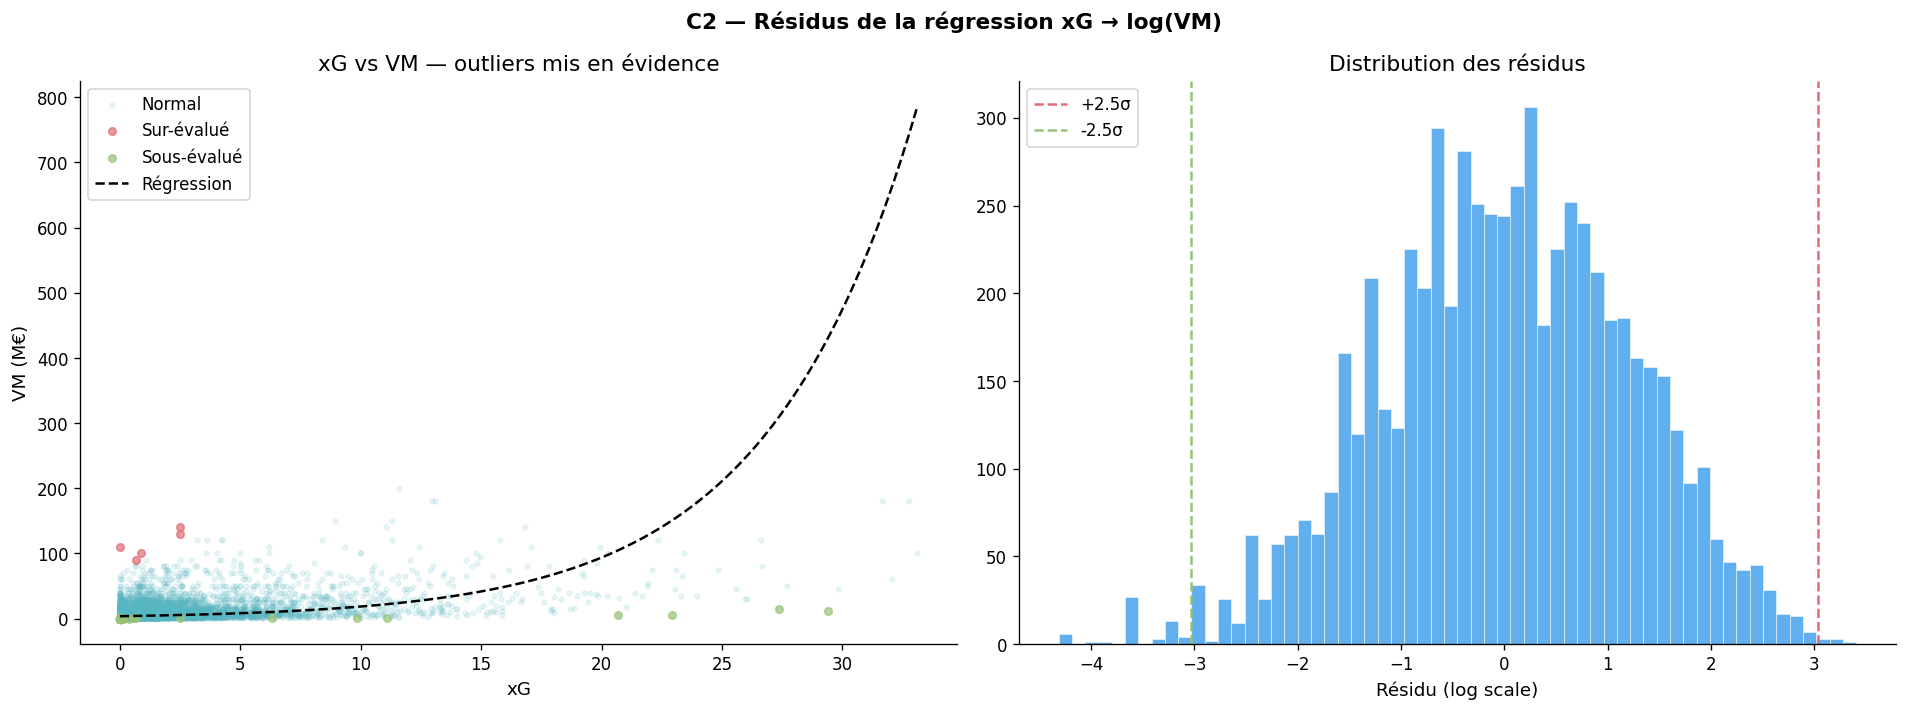

In [119]:
# Résidus régression simple xG → log(VM)

df_res = df[["player", "pos_simple", "league", "age", "xg", TARGET]].dropna().copy()
df_res = df_res[np.isfinite(df_res["xg"]) & (df_res[TARGET] > 0)]

X = df_res["xg"].values.reshape(-1, 1)
y = np.log1p(df_res[TARGET].values)

reg = LinearRegression().fit(X, y)
df_res["vm_pred_log"] = reg.predict(X)
df_res["residual"]    = y - df_res["vm_pred_log"]

# Outliers résidus (> 2.5 std)
std_r = df_res["residual"].std()
df_res["outlier_type"] = "Normal"
df_res.loc[df_res["residual"] >  2.5 * std_r, "outlier_type"] = "Sur-évalué"
df_res.loc[df_res["residual"] < -2.5 * std_r, "outlier_type"] = "Sous-évalué"

n_sur  = (df_res["outlier_type"] == "Sur-évalué").sum()
n_sous = (df_res["outlier_type"] == "Sous-évalué").sum()
print(f"\nRégression xG → log(VM)  |  R²={reg.score(X, y):.3f}")
print(f"  Sur-évalués  (résidu > +2.5σ) : {n_sur}")
print(f"  Sous-évalués (résidu < -2.5σ) : {n_sous}")

color_map = {"Normal": COLORS["cyan"], "Sur-évalué": COLORS["red"], "Sous-évalué": COLORS["green"]}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("C2 — Résidus de la régression xG → log(VM)", fontsize=13, fontweight="bold")

# Scatter xG vs VM avec outliers colorés
for group, color in color_map.items():
    sub = df_res[df_res["outlier_type"] == group]
    alpha = 0.12 if group == "Normal" else 0.7
    size  = 8    if group == "Normal" else 20
    axes[0].scatter(sub["xg"], sub[TARGET].values / 1e6,
                    alpha=alpha, s=size, color=color, label=group, rasterized=True)

x_line = np.linspace(df_res["xg"].min(), df_res["xg"].max(), 100).reshape(-1, 1)
axes[0].plot(x_line, np.expm1(reg.predict(x_line)) / 1e6,
             color="black", lw=1.5, linestyle="--", label="Régression")
axes[0].set_xlabel("xG")
axes[0].set_ylabel("VM (M€)")
axes[0].set_title("xG vs VM — outliers mis en évidence")
axes[0].legend()

# Distribution des résidus
axes[1].hist(df_res["residual"], bins=60, color=COLORS["blue"], edgecolor="white", linewidth=0.3)
axes[1].axvline( 2.5 * std_r, color=COLORS["red"],   linestyle="--", label="+2.5σ")
axes[1].axvline(-2.5 * std_r, color=COLORS["green"],  linestyle="--", label="-2.5σ")
axes[1].set_title("Distribution des résidus")
axes[1].set_xlabel("Résidu (log scale)")
axes[1].legend()

plt.tight_layout()
plt.savefig(dossier_sortie / "outliers_residus.png")
print("outliers_residus.png sauvegardé")
plt.show()

In [120]:
# Top sur/sous-évalués
print("\nTop 10 joueurs les plus SUR-évalués vs xG :")
cols_show = ["player", "pos_simple", "league", "age", "xg", TARGET, "residual"]
cols_show = [c for c in cols_show if c in df_res.columns]
top_sur = df_res[df_res["outlier_type"] == "Sur-évalué"].sort_values("residual", ascending=False).head(10)
top_sur[TARGET] = (top_sur[TARGET] / 1e6).round(1)
print(top_sur[cols_show].to_string(index=False))

print("\nTop 10 joueurs les plus SOUS-évalués vs xG :")
top_sous = df_res[df_res["outlier_type"] == "Sous-évalué"].sort_values("residual").head(10)
top_sous[TARGET] = (top_sous[TARGET] / 1e6).round(1)
print(top_sous[cols_show].to_string(index=False))


Top 10 joueurs les plus SUR-évalués vs xG :
           player pos_simple             league  age       xg  market_value_in_eur  residual
            Rodri         MF ENG-Premier League 28.0 0.000000                110.0  3.404025
            Pedri         MF        ESP-La Liga 21.0 2.510431                140.0  3.238026
Eduardo Camavinga         MF        ESP-La Liga 20.0 0.875550                100.0  3.166711
Federico Valverde         MF        ESP-La Liga 26.0 2.511641                130.0  3.163722
   Moisés Caicedo         MF ENG-Premier League 22.0 0.691102                 90.0  3.091266

Top 10 joueurs les plus SOUS-évalués vs xG :
            player pos_simple      league  age       xg  market_value_in_eur  residual
     Niama Sissoko         FW FRA-Ligue 1 18.0 0.138512                  0.0 -4.314633
  Sofiane Sidi Ali         FW FRA-Ligue 1 28.0 0.068025                  0.0 -4.303201
     Prosper Peter         FW FRA-Ligue 1 16.0 0.000000                  0.0 -4.292168
   

In [121]:
print("Qualité et cohérence des données")

# Cohérence born vs age vs season
df["season_start"] = df["season"].apply(lambda x: int(str(x)[:2]) + 2000
                                         if len(str(x)) == 4 and str(x)[:2] != "20"
                                         else int(str(x)[:4]))
# Recalcul saison start depuis le code numérique
df["season_start2"] = df["season_label"].str[:4].astype(float)
df["age_calc"] = df["season_start2"] - df["born"]
df["age_diff"] = (df["age_calc"] - df["age"]).abs()

print(f"\nCohérence born/age/season :")
print(f"  Différence nulle (exacte)      : {(df['age_diff'] == 0).sum():,}")
print(f"  Différence ≤ 1 an              : {(df['age_diff'] <= 1).sum():,}")
print(f"  Différence > 1 an (anomalie)   : {(df['age_diff'] > 1).sum():,}")
print(f"  Différence > 5 ans             : {(df['age_diff'] > 5).sum():,}")

Qualité et cohérence des données

Cohérence born/age/season :
  Différence nulle (exacte)      : 9,801
  Différence ≤ 1 an              : 14,806
  Différence > 1 an (anomalie)   : 0
  Différence > 5 ans             : 0


In [ ]:
# Cohérence injury_days_total
injury_d_cols = [
    "injury_musculaire_nb_d", "injury_genou_nb_d", "injury_cheville_pied_nb_d",
    "injury_mollet_tibia_nb_d", "injury_dos_bassin_nb_d", "injury_trauma_severe_nb_d",
    "injury_medical_repos_nb_d", "injury_minor_unknown_nb_d"
]
injury_d_cols = [c for c in injury_d_cols if c in df.columns]
df["injury_sum_recomputed"] = df[injury_d_cols].sum(axis=1)
df["injury_diff"] = (df["injury_sum_recomputed"] - df["injury_days_total"]).abs()

print(f"\nCohérence injury_days_total vs somme des composantes :")
print(f"  Cohérents (diff = 0)           : {(df['injury_diff'] == 0).sum():,}")
print(f"  Diff ≤ 1 jour                  : {(df['injury_diff'] <= 1).sum():,}")
print(f"  Diff > 1 jour (anomalie)       : {(df['injury_diff'] > 1).sum():,}")
print(f"  Diff max                       : {df['injury_diff'].max():.0f} jours")


Cohérence injury_days_total vs somme des composantes :
  Cohérents (diff = 0)           : 16,443
  Diff ≤ 1 jour                  : 16,443
  Diff > 1 jour (anomalie)       : 679
  Diff max                       : 1214 jours



Évolution VM par saison :
              Médiane (M€)  Moyenne (M€)  Nb joueurs
season_label                                        
2020/21                5.0     10.460627      2649.0
2021/22                5.0     10.754859      2562.0
2022/23                5.0     11.359906      2665.0
2023/24                5.5     12.141676      2571.0
2024/25                6.0     13.170258      2420.0
2025/26                8.0     15.187433      2065.0
evolution_temporelle.png sauvegardé


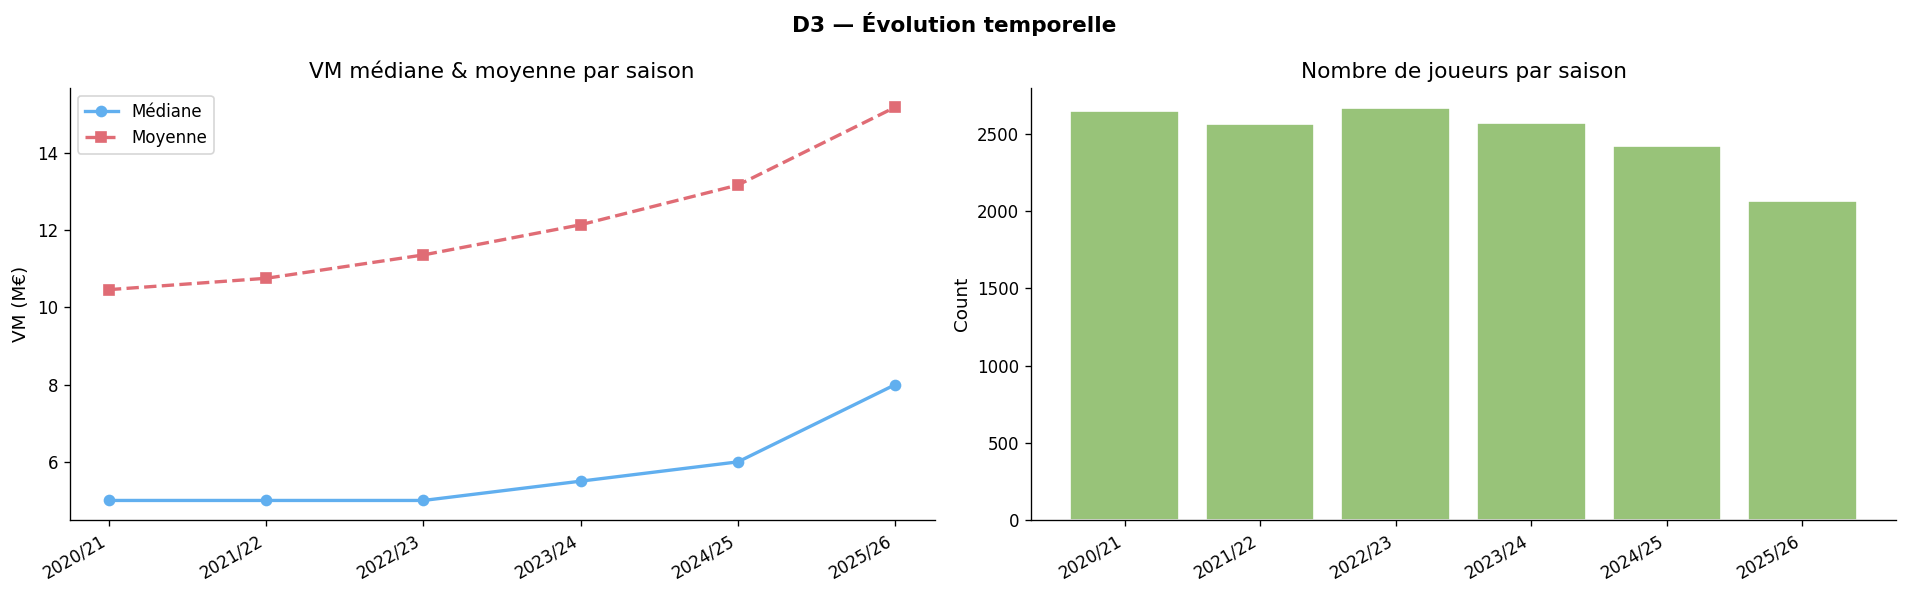

In [ ]:
# Évolution VM par saison
vm_season = (
    df.groupby("season_label")[TARGET]
    .agg(mediane="median", moyenne="mean", count="count")
    / np.array([1e6, 1e6, 1])
)
vm_season.columns = ["Médiane (M€)", "Moyenne (M€)", "Nb joueurs"]
print(f"\nÉvolution VM par saison :")
print(vm_season.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("D3 — Évolution temporelle", fontsize=13, fontweight="bold")

seasons = vm_season.index.tolist()
axes[0].plot(seasons, vm_season["Médiane (M€)"], marker="o", color=COLORS["blue"],  label="Médiane", lw=2)
axes[0].plot(seasons, vm_season["Moyenne (M€)"], marker="s", color=COLORS["red"],   label="Moyenne", lw=2, linestyle="--")
axes[0].set_title("VM médiane & moyenne par saison")
axes[0].set_ylabel("VM (M€)")
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")

axes[1].bar(seasons, vm_season["Nb joueurs"], color=COLORS["green"], edgecolor="white")
axes[1].set_title("Nombre de joueurs par saison")
axes[1].set_ylabel("Count")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(dossier_sortie / "evolution_temporelle.png")
print("evolution_temporelle.png sauvegardé")
plt.show()